# Yandex: Geo Reviews Dataset 2023

- Адрес организации - `address`
- Название организации - `name_ru`
- Список рубрик, к которым относится организация - `rubrics`
- Оценка пользователя от 0 до 5 - `rating`
- Текст отзыва - `text`

### Импорт библиотек

In [4]:
!pip install kagglehub


   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   -------------------- ------------------- 1/2 [kagglehub]
   ---------------------------------------- 2/2 [kagglehub]



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import kagglehub

import nltk
from nltk.corpus import stopwords
from tqdm import tqdm
from nltk.stem import SnowballStemmer
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.model_selection import train_test_split

from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import SGDRegressor
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet



import warnings
warnings.filterwarnings('ignore')


In [2]:
!pip install nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

### Подготовка данных

In [17]:
df = pd.read_csv('geo-reviews-dataset-2023.csv')
display(df)

,address,name_ru,rating,rubrics,text
0,"Екатеринбург, ул. Московская / ул. Волгоградск...",Московский квартал,3.0,Жилой комплекс,Московский квартал 2.\nШумно : летом по ночам ...
1,"Московская область, Электросталь, проспект Лен...",Продукты Ермолино,5.0,Магазин продуктов;Продукты глубокой заморозки;...,"Замечательная сеть магазинов в общем, хороший ..."
2,"Краснодар, Прикубанский внутригородской округ,...",LimeFit,1.0,Фитнес-клуб,"Не знаю смутят ли кого-то данные правила, но я..."
3,"Санкт-Петербург, проспект Энгельса, 111, корп. 1",Snow-Express,4.0,Пункт проката;Прокат велосипедов;Сапсёрфинг,Хорошие условия аренды. \nДружелюбный персонал...
4,"Тверь, Волоколамский проспект, 39",Студия Beauty Brow,5.0,"Салон красоты;Визажисты, стилисты;Салон бровей...",Топ мастер Ангелина топ во всех смыслах ) Немн...
...,...,...,...,...,...
499995,"Москва, Южный административный округ, район Би...",Бирюлёво-Пассажирская,4.0,Железнодорожная станция,"Охрана кривая но добрая, двери не закрываются ..."
499996,"Москва, Южный административный округ, район Би...",Бирюлёво-Пассажирская,4.0,Железнодорожная станция,По сравнению со многими современными платформа...
499997,"Новосибирск, Коммунистическая улица, 48А",NaN,5.0,"Бар, паб","Приятная атмосфера, прекрасное вино, волшебная..."
499998,"Астраханская область, Харабалинский район",Сарай-Бату,5.0,Достопримечательность,Был с семьёй 13.06.23 Отличное место. Рекоменд...


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 5 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   address  500000 non-null  object 
 1   name_ru  499030 non-null  object 
 2   rating   500000 non-null  float64
 3   rubrics  500000 non-null  object 
 4   text     500000 non-null  object 
dtypes: float64(1), object(4)
memory usage: 19.1+ MB


In [19]:
train_df = df.copy()

In [20]:
train_df.duplicated().sum()

np.int64(1)

In [21]:
train_df[train_df.duplicated()]

,address,name_ru,rating,rubrics,text
124087,"Красноярск, Ястынская улица, 14",Спарта Маркет,5.0,Автоакустика;Тонирование автостёкол;Плёнки арх...,"Хорошие консультанты, вежливые.\nВсе помогли ,..."


In [22]:
train_df = train_df.drop_duplicates()

In [23]:
train_df.isna().sum().sort_values(ascending=False)

name_ru    970
address      0
rating       0
rubrics      0
text         0
dtype: int64

In [24]:
train_df[train_df['name_ru'].isna()]

,address,name_ru,rating,rubrics,text
322,"Москва, 8-я улица Соколиной Горы, 15А, стр. 23",NaN,5.0,Офис организации,"Ребята профи!\n\nОтлично подобрали модель, съе..."
5716,"Челябинская область, Златоуст, Таганайская ули...",NaN,5.0,Гостиница,"Гостиница действительно хорошая, удобно распол..."
5717,"Челябинская область, Златоуст, Таганайская ули...",NaN,5.0,Гостиница,Был здесь на кулинарном мастер-классе. Место а...
5718,"Челябинская область, Златоуст, Таганайская ули...",NaN,5.0,Гостиница,"Тихое место, в выходные возможно и шумно так к..."
5719,"Челябинская область, Златоуст, Таганайская ули...",NaN,5.0,Гостиница,"Воспитанные и отзывчивые официанты , вкусная к..."
...,...,...,...,...,...
498536,"Республика Башкортостан, Уфа, улица Менделеева...",NaN,5.0,"Скалодром;Спортивный клуб, секция",Были с детьми на 8 марта. Приехали специально ...
498688,"Москва, Юго-Восточный административный округ, ...",NaN,5.0,Изготовление памятников и надгробий;Изделия из...,"Отличное качество материала, прекрасное исполн..."
498913,"Самарская область, Волжский район, жилой район...",NaN,1.0,Магазин цветов;Копировальный центр;Товары для ...,"Цен на цветы которые находятся на витрине нет,..."
499006,"Волгоград, улица Гроссмана, 6",NaN,5.0,Салон красоты,Квалифицированные мастера. Работу выполняют с ...


In [25]:
train_df['name_ru'] = train_df['name_ru'].fillna('Без названия')

In [26]:
train_df['name_ru'].isna().sum()

np.int64(0)

In [27]:
" ".join(sorted(set("".join(train_df['rubrics']))))

'  ( ) , - 1 3 ; D F G I P R S T V W i Ё А Б В Г Д Е Ж З И К Л М Н О П Р С Т У Ф Х Ц Ч Ш Э Ю Я а б в г д е ж з и й к л м н о п р с т у ф х ц ч ш щ ъ ы ь э ю я ё \u200b'

In [28]:
#u200b_mask = train_df['rubrics'].str.contains('\u200b', regex=False)
#train_df[u200b_mask].head()

In [29]:
#rasp_center_mask = train_df['rubrics'].str.contains('Распределительный центр', case=False, regex=False)
#train_df[rasp_center_mask]

In [30]:
#special_chars_mask = train_df['rubrics'].str.contains(r'[0-9\(\)\-]', regex=True)
#train_df[special_chars_mask]

In [31]:
train_df['rubrics'] = train_df['rubrics'].astype(str).str.replace('\u200b', '', regex=False)

In [32]:
first = train_df['address'].str.split(',').str[0].str.strip()

mask = first.str.contains('область|край|республика|округ|АО|Москва|Санкт-Петербург|Севастополь', case=False, regex=True)
#train_df[mask]
#exceptions = first[~mask]
#exceptions.unique()

In [33]:
regions = first[mask].value_counts()

In [34]:
regions

address
Москва                             104774
Санкт-Петербург                     52568
Московская область                  49953
Краснодарский край                  29646
Республика Татарстан                11662
                                    ...  
Черная Кость Московская область         1
г. Санкт-Петербург                      1
Камчатская область                      1
городской округ Вологда                 1
Адрес: Московская область               1
Name: count, Length: 149, dtype: int64

In [35]:
print(regions.to_string())

address
Москва                                                            104774
Санкт-Петербург                                                    52568
Московская область                                                 49953
Краснодарский край                                                 29646
Республика Татарстан                                               11662
Свердловская область                                               11617
Ленинградская область                                               8409
Республика Крым                                                     8128
Ставропольский край                                                 6452
Республика Башкортостан                                             6246
Ростовская область                                                  5631
Самарская область                                                   3396
Приморский край                                                     3125
Республика Дагестан                        

In [36]:
cities = first[~mask].value_counts()
cities

address
Краснодар                        9073
Нижний Новгород                  8545
Ростов-на-Дону                   7781
Самара                           5736
Воронеж                          5457
                                 ... 
Симферопольское шоссе               1
Карелия                             1
линия Пермь II – Екатеринбург       1
улица Победы                        1
Окситания                           1
Name: count, Length: 311, dtype: int64

In [37]:
print(cities.to_string())

address
Краснодар                                                                 9073
Нижний Новгород                                                           8545
Ростов-на-Дону                                                            7781
Самара                                                                    5736
Воронеж                                                                   5457
Новосибирск                                                               4972
Волгоград                                                                 3821
Калининград                                                               3663
Ярославль                                                                 3589
Челябинск                                                                 3298
Пермь                                                                     3268
Саратов                                                                   3258
Тула                                        

In [38]:
counts = regions.values
threshold = np.percentile(counts, 75)
main_regions = regions[regions.values > threshold]

In [39]:
main_regions

address
Москва                               104774
Санкт-Петербург                       52568
Московская область                    49953
Краснодарский край                    29646
Республика Татарстан                  11662
Свердловская область                  11617
Ленинградская область                  8409
Республика Крым                        8128
Ставропольский край                    6452
Республика Башкортостан                6246
Ростовская область                     5631
Самарская область                      3396
Приморский край                        3125
Республика Дагестан                    3076
Севастополь                            2982
Нижегородская область                  2751
Владимирская область                   2700
Республика Карелия                     2671
Алтайский край                         2472
Удмуртская Республика                  2393
Челябинская область                    2340
Чувашская Республика                   2338
Калининградская область 

In [40]:
main_regions.count()

np.int64(37)

In [41]:
counts_cities = cities.values
threshold_cities = np.percentile(counts_cities, 87)
main_cities = cities[cities.values > threshold_cities]

In [42]:
main_cities

address
Краснодар                         9073
Нижний Новгород                   8545
Ростов-на-Дону                    7781
Самара                            5736
Воронеж                           5457
Новосибирск                       4972
Волгоград                         3821
Калининград                       3663
Ярославль                         3589
Челябинск                         3298
Пермь                             3268
Саратов                           3258
Тула                              3129
Красноярск                        3106
Тюмень                            2511
Рязань                            2403
Омск                              2398
Тверь                             2328
Владимир                          2082
Иркутск                           1995
Калуга                            1988
Ульяновск                         1910
Оренбург                          1790
посёлок городского типа Сириус    1776
Ставрополь                        1756
Липецк           

In [43]:
main_cities.count()

np.int64(41)

In [44]:
all_address = set(main_regions.index) | set(main_cities.index)

In [45]:
all_address

{'Алтайский край',
 'Астрахань',
 'Белгород',
 'Брянск',
 'Великий Новгород',
 'Владимир',
 'Владимирская область',
 'Волгоград',
 'Волгоградская область',
 'Вологда',
 'Вологодская область',
 'Воронеж',
 'Воронежская область',
 'Иваново',
 'Иркутск',
 'Иркутская область',
 'Кабардино-Балкарская Республика',
 'Калининград',
 'Калининградская область',
 'Калуга',
 'Калужская область',
 'Кемеровская область',
 'Киров',
 'Кострома',
 'Краснодар',
 'Краснодарский край',
 'Красноярск',
 'Красноярский край',
 'Курск',
 'Ленинградская область',
 'Липецк',
 'Москва',
 'Московская область',
 'Нижегородская область',
 'Нижний Новгород',
 'Новосибирск',
 'Омск',
 'Оренбург',
 'Пенза',
 'Пермь',
 'Приморский край',
 'Псков',
 'Республика Адыгея',
 'Республика Башкортостан',
 'Республика Дагестан',
 'Республика Карелия',
 'Республика Крым',
 'Республика Татарстан',
 'Ростов-на-Дону',
 'Ростовская область',
 'Рязань',
 'Самара',
 'Самарская область',
 'Санкт-Петербург',
 'Саратов',
 'Саратовская обл

In [46]:
train_df['location'] = first.where(first.isin(all_address))

In [47]:
train_df['address'].nunique()

191925

In [48]:
train_df['location'].isna().sum()

np.int64(35364)

In [49]:
train_df = train_df.dropna(subset=['location'])
train_df

,address,name_ru,rating,rubrics,text,location
1,"Московская область, Электросталь, проспект Лен...",Продукты Ермолино,5.0,Магазин продуктов;Продукты глубокой заморозки;...,"Замечательная сеть магазинов в общем, хороший ...",Московская область
2,"Краснодар, Прикубанский внутригородской округ,...",LimeFit,1.0,Фитнес-клуб,"Не знаю смутят ли кого-то данные правила, но я...",Краснодар
3,"Санкт-Петербург, проспект Энгельса, 111, корп. 1",Snow-Express,4.0,Пункт проката;Прокат велосипедов;Сапсёрфинг,Хорошие условия аренды. \nДружелюбный персонал...,Санкт-Петербург
4,"Тверь, Волоколамский проспект, 39",Студия Beauty Brow,5.0,"Салон красоты;Визажисты, стилисты;Салон бровей...",Топ мастер Ангелина топ во всех смыслах ) Немн...,Тверь
5,"Иркутская область, Черемхово, Первомайская ули...",Tele2,5.0,Оператор сотовой связи;Интернет-провайдер,"Приятное общение, все доступно объяснили, мне ...",Иркутская область
...,...,...,...,...,...,...
499993,"Москва, Южный административный округ, район Би...",Бирюлёво-Пассажирская,5.0,Железнодорожная станция,Отличный пересадочный узел. \n,Москва
499994,"Москва, Южный административный округ, район Би...",Бирюлёво-Пассажирская,5.0,Железнодорожная станция,Хороший способ избежать автобусной пытки. Элек...,Москва
499995,"Москва, Южный административный округ, район Би...",Бирюлёво-Пассажирская,4.0,Железнодорожная станция,"Охрана кривая но добрая, двери не закрываются ...",Москва
499996,"Москва, Южный административный округ, район Би...",Бирюлёво-Пассажирская,4.0,Железнодорожная станция,По сравнению со многими современными платформа...,Москва


### Разделение данных

##### Разделим наш датасет на train/val/test в стандартном соотношении 80:10:10

In [50]:
train, val_test = train_test_split(train_df, test_size=0.2, random_state=42)
val, test = train_test_split(val_test, test_size=0.5, random_state=42)

In [51]:
display(train.shape[0])
display(val.shape[0])
display(test.shape[0])

371708

46463

46464

### Rating
##### Анализ рейтинга заведения

In [52]:
train['rating'].value_counts()

rating
5.0    291265
4.0     29973
1.0     25514
3.0     15855
2.0      8955
0.0       146
Name: count, dtype: int64

<Axes: xlabel='rating'>

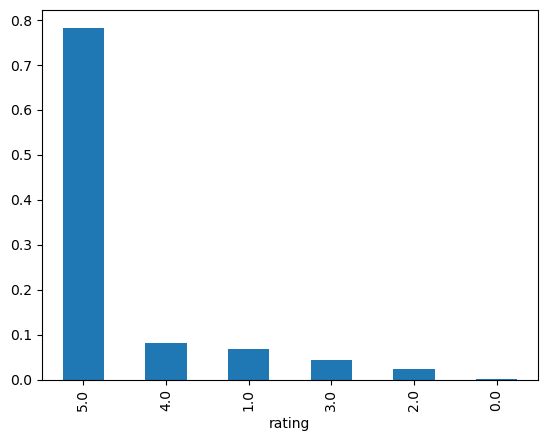

In [53]:
train_df['rating'].value_counts(normalize=True).plot(kind='bar')

Распределение рейтинга неравномерное, огромную долю составляет рейтинг 5.0, рейтинг 0.0 практически не встречается.

Использовать сырой признак `rating` малоинформативно, потмоу что модель не понимает смысл рейтинга, она рассматривает оценку рейтинга как вклад в масштабе, поэтому используем отклонение от выставленного рейтинга. Так модель будет видеть направление, а не масштаб. За стандартную оценку возьмем рейтинг 3

In [54]:
train['rating_bias'] = train['rating'] - 3

val['rating_bias'] = val['rating'] - 3
test['rating_bias'] = test['rating'] - 3

In [55]:
train['rating_bias'].value_counts()

rating_bias
 2.0    291265
 1.0     29973
-2.0     25514
 0.0     15855
-1.0      8955
-3.0       146
Name: count, dtype: int64

Так как большую часть наших данных составляют оценки рейтинга 5 и 1 (которые выражают сильную эмоциональность пользователя), то другие оценки также перестают быть информативными. Создадим бинарный признак для рейтинга 5 и 1

In [56]:
train['rating_emotion'] = train['rating'].isin([1, 5]).astype(int)

val['rating_emotion'] = val['rating'].isin([1, 5]).astype(int)
test['rating_emotion'] = test['rating'].isin([1, 5]).astype(int)

In [57]:
train['rating_emotion'].value_counts()

rating_emotion
1    316779
0     54929
Name: count, dtype: int64

### Rubrics
##### Анализ типа заведения

In [58]:
train['rubrics'].value_counts()

rubrics
Гостиница                                                                                                  30484
Ресторан                                                                                                   11140
Кафе                                                                                                        8428
Супермаркет                                                                                                 6392
Музей                                                                                                       3722
                                                                                                           ...  
Товары для интерьера;Магазин обоев;Магазин ткани;Магазин посуды                                                1
Дизайн интерьеров;Курсы и мастер-классы;Студия дизайна                                                         1
Магазин цветов;Удобрения                                                                

In [59]:
train['rubrics'].nunique()

27050

Признак `rubrics` содержит списки категорий, где каждая комбинация тегов является уникальным значением, что приводит к большой размерности данных (**30310** уникальных значений). Для дальнейшего удобства анализа и обучения модели мы декомпозируем составные категории, извлекая каждый тег из списка, это позволит выделить меньшее количество уникальных категорий.

Для этого используем метод *explode*:
```python
#Transform each element of a list-like to a row, replicating index values

DataFrame.explode(column, ignore_index=False)
```
*Источник*: [DataFrame.explode](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.explode.html)

Рассмотрим все символы, которые есть у нас в этих категориях:

In [60]:
rubrics_df = train.copy()

rubrics_df['rubrics'] = rubrics_df['rubrics'].str.split(';')
rubrics_df = rubrics_df.explode('rubrics')

In [61]:
rubrics_df

,address,name_ru,rating,rubrics,text,location,rating_bias,rating_emotion
456761,"Московская область, Одинцово, Можайское шоссе,...",Pets Groom,4.0,"Зоосалон, зоопарикмахерская",Мне очень понравился этот салон особенно масте...,Московская область,1.0,0
401622,"Тверь, улица Хромова, 17, корп. 1",Воображуля,5.0,Парикмахерская,После посещения парикмахерской Воображуля оста...,Тверь,2.0,1
401622,"Тверь, улица Хромова, 17, корп. 1",Воображуля,5.0,Салон красоты,После посещения парикмахерской Воображуля оста...,Тверь,2.0,1
173213,"Москва, Комсомольская площадь, 2",Казанский вокзал,4.0,Железнодорожный вокзал,Изменения в лучшую сторону на лицо. Становится...,Москва,1.0,0
151589,"Свердловская область, Каменск-Уральский, просп...",Бургер Кинг,5.0,Быстрое питание,"Очень вкусные бургеры, закуски, мороженое. Пос...",Свердловская область,2.0,1
...,...,...,...,...,...,...,...,...
141962,"Воронеж, улица Шишкова, 146Б",ЛОГОПЕДиУМ,5.0,Логопеды,Прекрасно место для детей . Трепетное отношени...,Воронеж,2.0,1
158016,"Кемеровская область, Прокопьевск, Ноградская у...",Хозцентр,5.0,Товары для дома,"Просто счастье ,что его открыли.я так по нему ...",Кемеровская область,2.0,1
158016,"Кемеровская область, Прокопьевск, Ноградская у...",Хозцентр,5.0,Электро- и бензоинструмент,"Просто счастье ,что его открыли.я так по нему ...",Кемеровская область,2.0,1
158016,"Кемеровская область, Прокопьевск, Ноградская у...",Хозцентр,5.0,Магазин для садоводов,"Просто счастье ,что его открыли.я так по нему ...",Кемеровская область,2.0,1


In [62]:
rubrics_df['rubrics'].nunique()

1356

In [63]:
rubrics_df['rubrics'].value_counts()

rubrics
Ресторан                   43539
Кафе                       43205
Гостиница                  31037
Магазин продуктов          15352
Бар, паб                   14741
                           ...  
Пункт вакцинации               1
Аграрная инфраструктура        1
Таксофон                       1
Красители для ткани            1
Прокладка кабеля               1
Name: count, Length: 1356, dtype: int64

<Axes: >

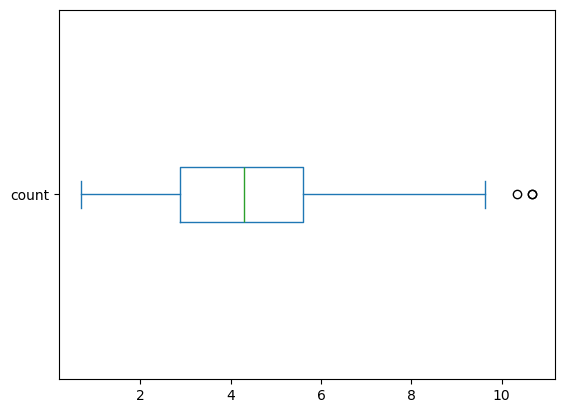

In [64]:
np.log1p(rubrics_df['rubrics'].value_counts()).plot(kind='box', vert=False)

При анализе распределения количества отзывов по рубрикам видно, что большинство рубрик имеют очень мало отзывов, которые создают шум для моделей впоследствии. Рубрики, которые находятся выше 97,5 перцентиля (особенно в зоне выбросов) это и есть рубрики с очень большим числом отзывов (Ресторан, Гостиница). В нашем случае мы оставляем именно аномальные значения, так как они формируют статистику отзывов и представляют самые значимые категории.

In [65]:
counts = rubrics_df['rubrics'].value_counts().values
threshold = np.percentile(counts, 97.5)
main_rubrics = rubrics_df['rubrics'].value_counts()[rubrics_df['rubrics'].value_counts() > threshold].index

In [66]:
rubrics_df = rubrics_df[rubrics_df['rubrics'].isin(main_rubrics)]
rubrics_df['rubrics'].value_counts()

rubrics
Ресторан                               43539
Кафе                                   43205
Гостиница                              31037
Магазин продуктов                      15352
Бар, паб                               14741
Супермаркет                            14354
Салон красоты                          14005
Быстрое питание                        12640
Доставка еды и обедов                  10860
Ногтевая студия                         9101
Автосервис, автотехцентр                8239
Кофейня                                 8047
Пиццерия                                7379
Парикмахерская                          7378
Банкетный зал                           6932
Музей                                   6925
Медцентр, клиника                       6328
Парк культуры и отдыха                  6152
Торговый центр                          6095
Развлекательный центр                   5721
Косметология                            5592
Стоматологическая клиника               5346
Су

In [67]:
len(set(rubrics_df.index))

219492

##### Проанализируем соотношение рейтинга заведения и кол-во оставленных отзывов

In [68]:
rubrics_df.groupby('rubrics')['rating'].agg(['mean','count']).sort_values('mean', ascending=False)

,mean,count
rubrics,,
Массажный салон,4.772145,3748
Музей,4.760289,6925
Салон бровей и ресниц,4.731331,3562
Косметология,4.715844,5592
Парк культуры и отдыха,4.679941,6152
Салон красоты,4.679686,14005
Достопримечательность,4.665839,4833
Стоматологическая клиника,4.648522,5346
Ногтевая студия,4.642567,9101


- Массажный салон **4.77** **(3748 отзывов)**     
Высокий рейтинг, но выборка небольшая. Несколько пятёрок могут сильно завышать среднее значение

- Ресторан **4.46** **(43539 отзывов)**  
Очень большая выборка, поэтому рейтинг стабильный, но ниже из‑за большого количества негативных отзывов (опять же, так как выборка больше)

- Супермаркет **4.31** **(14354 отзывов)**    
Много отзывов, много негатива, поэтому средний рейтинг ниже

Категории с высоким средним рейтингом не обязательно являются лучшими по данной выборке, т.к. у них меньше отзывов и несколько высоких оценок поднимают среднее значение.

In [69]:
display(rubrics_df.groupby('rubrics')['rating'].std().sort_values(ascending=False).head(10))
display(rubrics_df.groupby('rubrics')['rating'].std().sort_values(ascending=False).tail(10))

rubrics
Суши-бар                               1.404614
Шиномонтаж                             1.392698
Быстрое питание                        1.365732
Доставка еды и обедов                  1.296286
Пиццерия                               1.279159
Автосервис, автотехцентр               1.278735
Магазин автозапчастей и автотоваров    1.254709
Медцентр, клиника                      1.244320
Магазин продуктов                      1.205757
Пекарня                                1.201231
Name: rating, dtype: float64

rubrics
Салон красоты             1.011893
Развлекательный центр     0.978196
Гостиница                 0.977011
Косметология              0.952970
Торговый центр            0.944536
Салон бровей и ресниц     0.922721
Достопримечательность     0.838751
Массажный салон           0.833866
Парк культуры и отдыха    0.778387
Музей                     0.705274
Name: rating, dtype: float64

Высокий разброс std в начале списка подтверждает, что средняя оценка формируется из крайностей выставления оценок пользователя(то есть огромного числа пятерок и такого же числа единиц/двоек в рейтинге)

Там где разброс минимальный, std около средних значений, поэтому в данных категориях (таких как музеи и салоны красоты) средний рейтинг абсолютно честный.

Обычная сортировка категорий заведений по среднему рейтингу не совсем корректна, так как среднее сильно зависит от того, сколько отзывов собрала данная категория. Некоторые категории держат высокий рейтинг просто потому что у них мало клиентов и почти нет негатива. Поэтому можно использовать для анализа Байесовское среднее, которое будет анализировать рубрику в равных условиях, то есть будет брать среднюю оценку по всему рынку и добавлять часть таких средних отзывов каждой категории

In [70]:
mean_rating = rubrics_df.groupby('rubrics')['rating'].agg(['mean', 'count']).reset_index()

all_mean = rubrics_df['rating'].mean()
mean_rating_rubrics = mean_rating['count'].median()

mean_rating['bayes_rating'] = (mean_rating['count'] * mean_rating['mean'] + mean_rating_rubrics * all_mean) / (mean_rating['count'] + mean_rating_rubrics)

In [71]:
mean_rating.sort_values('bayes_rating', ascending=False)

,rubrics,mean,count,bayes_rating
17,Музей,4.760289,6925,4.627238
26,Салон красоты,4.679686,14005,4.618009
10,Косметология,4.715844,5592,4.591243
15,Массажный салон,4.772145,3748,4.589366
20,Парк культуры и отдыха,4.679941,6152,4.579050
18,Ногтевая студия,4.642567,9101,4.576272
25,Салон бровей и ресниц,4.731331,3562,4.571066
6,Достопримечательность,4.665839,4833,4.560877
19,Парикмахерская,4.624831,7378,4.558275
28,Стоматологическая клиника,4.648522,5346,4.557534


In [72]:
def categorize(row):
    food = ('Кафе', 'Кофейня', 'Ресторан', 'Быстрое питание', 'Доставка еды и обедов',
              'Пекарня', 'Столовая', 'Бар, паб', 'Суши-бар', 'Кальян-бар',
              'Банкетный зал', 'Кондитерская', 'Пиццерия')
    beauty = ('Салон красоты', 'Салон бровей и ресниц', 'Ногтевая студия', 'Парикмахерская', 'Фитнес-клуб')
    medicine = ('Косметология', 'Массажный салон', 'Медцентр, клиника', 'Стоматологическая клиника')
    culture = ('Развлекательный центр', 'Достопримечательность', 'Парк культуры и отдыха', 'Музей')
    auto = ('Автосервис, автотехцентр', 'Шиномонтаж', 'Магазин автозапчастей и автотоваров')
    store = ('Магазин продуктов', 'Супермаркет', 'Пункт выдачи', 'Магазин хозтоваров и бытовой химии', 'Торговый центр')

    if any(cat in row for cat in food):
        return 'Еда'
    if any(cat in row for cat in beauty):
        return 'Красота'
    if any(cat in row for cat in medicine):
        return 'Медицина'
    if any(cat in row for cat in culture):
        return 'Культура'
    if any(cat in row for cat in auto):
        return 'Автосервисы'
    if any(cat in row for cat in store):
        return 'Магазины'
    if 'Гостиница' in row:
        return 'Гостиницы'

In [73]:
train['group'] = train['rubrics'].apply(categorize)
train= train[~train['group'].isna()]

In [74]:
val['group'] = val['rubrics'].apply(categorize)
val = val[~val['group'].isna()]

In [75]:
test['group'] = test['rubrics'].apply(categorize)
test = test[~test['group'].isna()]

Катетегории после сглаживания практически не изменились, что говорит о том, что у нас нет случайных лидеров по рейтингу оценок, и они  подтверждены большим кол-вом реальных отзывов

##### Анализ распределения длины отзыва
В данных отзывов и рейтингов почти всегда присутствует сильная асимметрия, большая часть людей оставляет короткие отзывы (иногда вообще состоящие из 2 слов), а другие пишут более развернутые, из-за чего образуется длинный хвост распределения.

Поэтому из-за такого разброса смотреть на обычное среднее значение не имеет смысла, так как некоторое кол-во длинных отзывов сильно исказит цифры. Поэтому рассмотрим наше распределение по перцентилям.

In [76]:
train['text'].astype(str).str.len().describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99])

count    223187.000000
mean        299.765936
std         283.891836
min           3.000000
50%         214.000000
75%         361.000000
90%         590.000000
95%         797.000000
99%        1405.000000
max       13339.000000
Name: text, dtype: float64

Половина всех отзывов имеет длину от **219** символов, что эквивалентно полноценному абзацу текста

Однако данные имеют сильную правостороннюю асимметрию. Основная масса пользователей (**90%**) укладывается в 605 символов, тогда как оставшиеся **10%** оставляют огромные объемы текста вплоть до **7591**

Интуитивно понятно, что удовлетворенный клиент почти не тратит свое время на написание длинных отзывов, ему достаточно поставить 5 звезд и написать пару предложений. Слишком длинные отзывы, скорее всего, являются следствием негативного опыта, где недовольный клиент перечисляет все детали происходящего.

In [77]:
train['text'].astype(str).str.len().groupby(train['rating']).median()

rating
0.0    215.0
1.0    405.0
2.0    397.0
3.0    320.0
4.0    243.0
5.0    199.0
Name: text, dtype: float64

Длина текста сильно коррелирует с эмоциональностью выставленной оценки, чем ниже рейтинг, тем больше пользователь пишет

Медианная длина текста сильно зависит от эмоциональности отзыва
- Самые длинные отзывы оставляют пользователи с оценками **1.0 (медиана 422 символов)** и **2.0 (медиана 416 символа)**
- С ростом рейтинга до **5.0** медиана снижается до **203 символов**
- Отзывы с оценкой **0.0** (возможно отсутствие оценки) с медианой **237.5 символов**

Это доказывает наше предпположение выше, что главным фактором вовлеченности пользователей является их негативный опыт

##### Сравнение распределений длины текста по категориям

In [78]:
train['text'].astype(str).str.len().groupby(train['group']).median().sort_values(ascending=False)

group
Гостиницы      310.0
Медицина       264.0
Красота        238.0
Культура       211.0
Автосервисы    205.0
Еда            203.0
Магазины       168.0
Name: text, dtype: float64

Можно заметить, что длина отзывов существенно различается в зависимости от типа `group`. Разрыв между рубриками превышает 140 символов, поэтому возможно влияние контекста оказываемой услуги на поведение клиентов

- Максимальная длина отзывов (**241–324**)
  
    Для данной рубрики характерны сложные услуги, высокая стоимость и качество. Клиенты подробно описывают процесс обслуживания, результаты процедур и возникающие проблемы

- Средняя длина отзывов (**206–214**)

    Данные категории также связаны с качеством сервиса, но взаимодействие пользователя менее длительное и менее критичное (чем в той же медицине)

- Минимальная длина отзывов (**172**)

    Типичная транзакционная категория. Пользователи редко описывают детали, ограничиваясь короткими комментариями о наличии товара или скорости обслуживания

>В поведении пользователей есть устойчивая закономерность, чем важнее и сложнее для человека была услуга, тем больше усилий он тратит на описание своего опыта.
>- **Услуги низкой вовлечённости (эмоциональный опыт)**. Повседневные ситуации вроде покупки кофе или блюд. Решение принимается быстро, без анализа, поэтому и отзывы получаются короткими, т.к. пользователю просто нечего долго объяснять.
>- **Услуги высокой вовлечённости (рациональный опыт)** — это сложные сферы вроде медицины или крупного ремонта, где клиенту приходится сравнивать варианты, оценивать риски и внимательно следить за процессом.

Поэтому можно сделать вывод, что для сложных услуг длинные, содержательные отзывы это нормальная реакция пользователя и важный источник ценности для других клиентов.

*Источник:*  
*Jia, H., Shin, S., & Jiao, J. (2022).* [Does the length of a review matter in perceived helpfulness? The moderating role of product experience](https://openresearch.okstate.edu/server/api/core/bitstreams/05de9cd3-9bd9-4306-93f4-94dc00ac60bd/content)

##### Создадим нашу целевую переменную

In [79]:
train['len'] = train['text'].str.len()

val['len'] = val['text'].str.len()
test['len'] = test['text'].str.len()

<Axes: >

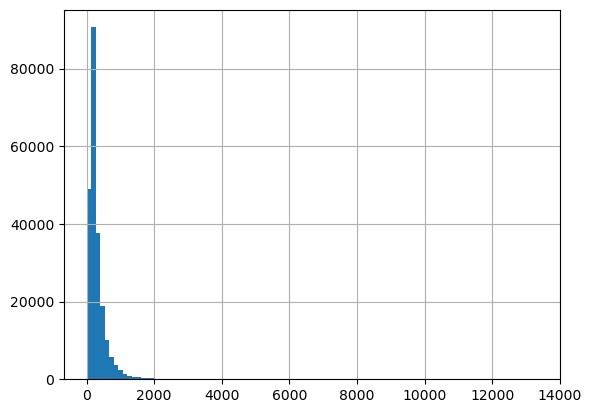

In [80]:
train['len'].hist(bins=100)

Длина текста сильно скошена вправо, основная масса оставленных отзывов короткие (до ~ 1500 символов), для нормальной структуры выведем логарифмированное значение

<Axes: >

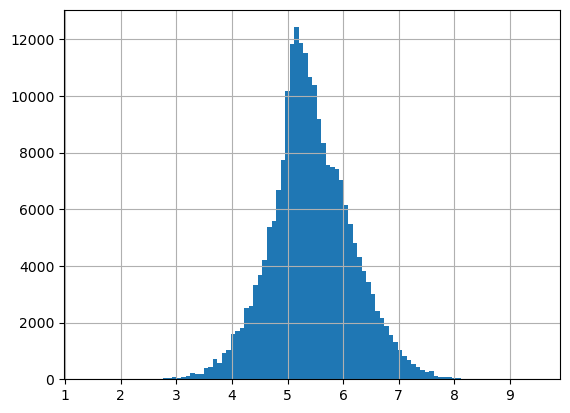

In [81]:
np.log1p(train['len']).hist(bins=100)

Логарифмирование стабилизировало масштаб и уменьшило влияние выбросов для анализа распределения

Рассмотрим распределение длинны отзыва по группам категорий:

<Axes: xlabel='group'>

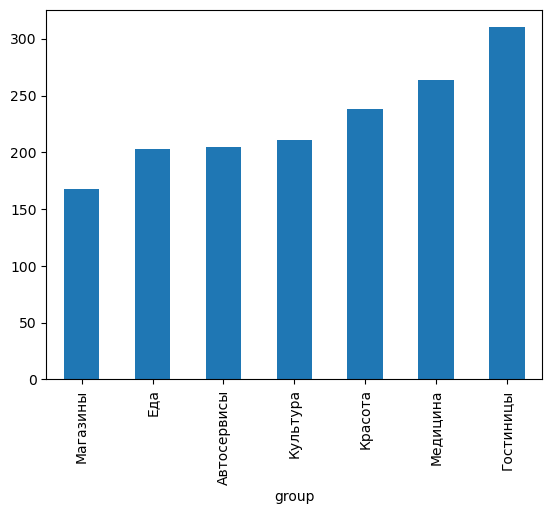

In [82]:
train.groupby('group')['len'].median().sort_values().plot(kind='bar')

### Location

In [83]:
train['location'].value_counts()

location
Москва                  49147
Санкт-Петербург         27213
Московская область      22370
Краснодарский край      15914
Республика Татарстан     5969
                        ...  
Иркутская область         548
Томск                     538
Вологодская область       532
Тамбов                    468
Красноярский край         460
Name: count, Length: 78, dtype: int64

##### Сравнение геолокации с характеристикой отзыва

In [84]:
train.groupby('location')['group'].value_counts()

location                        group    
Алтайский край                  Еда          444
                                Магазины     304
                                Гостиницы    132
                                Культура      76
                                Красота       62
                                            ... 
посёлок городского типа Сириус  Еда          312
                                Культура     204
                                Медицина      17
                                Магазины      12
                                Красота       11
Name: count, Length: 545, dtype: int64

Построим графики для топ 5 локаций для распределния категорий услуг:

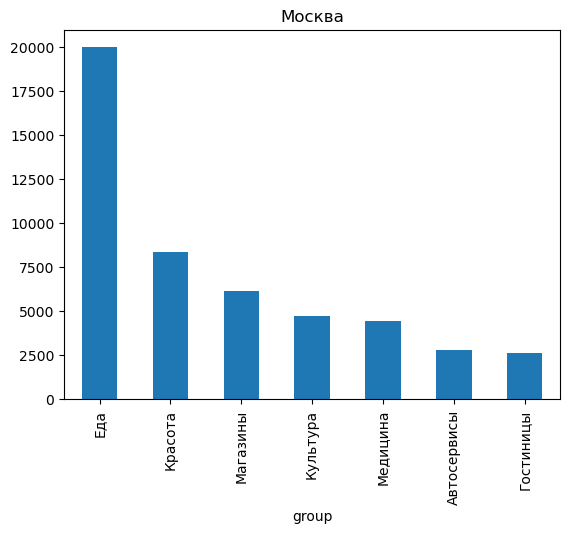

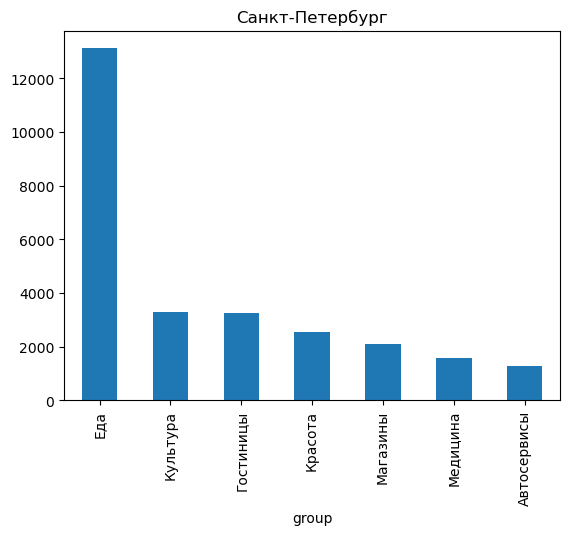

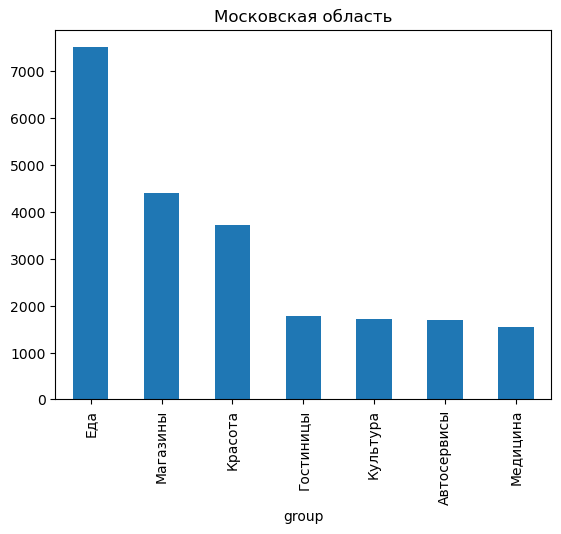

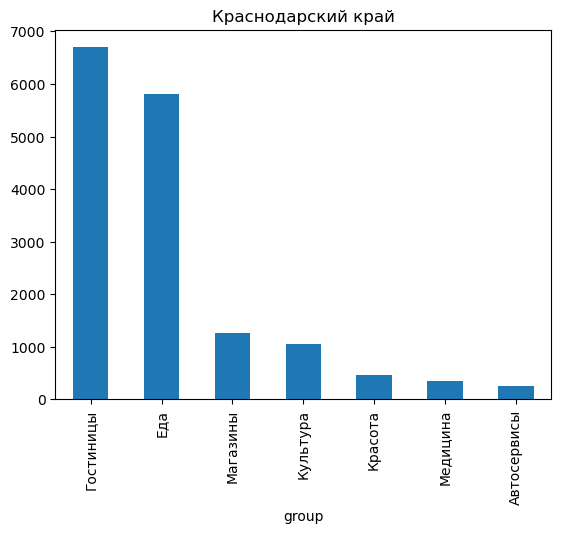

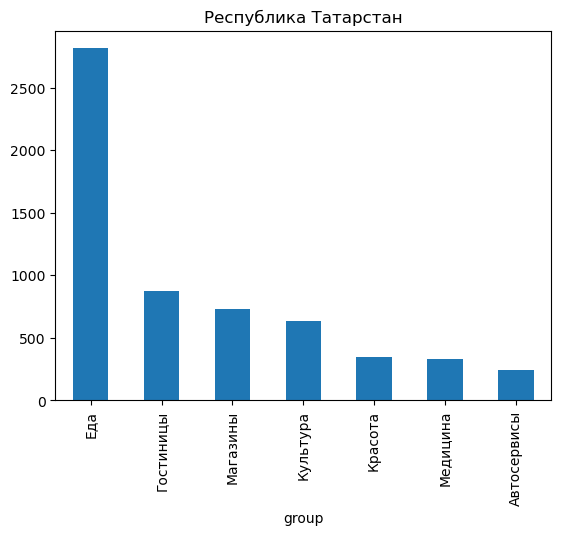

In [85]:
for city in train['location'].value_counts().head(5).index:
    train[train['location'] == city]['group'].value_counts().plot(kind='bar', title=city)
    plt.show()

Признаки `location` и `group` сильно взаимодействуют друг с другом и имеют сильный дисбаланс, так как поведение пользователей зависит от их региона.

In [86]:
train.groupby('location')['len'].max().sort_values(ascending=False)

location
Республика Крым          13339
Краснодар                 9777
Краснодарский край        8831
Санкт-Петербург           7591
Москва                    7508
                         ...  
Кемеровская область       1736
Удмуртская Республика     1625
Астрахань                 1556
Белгород                  1514
Красноярский край         1142
Name: len, Length: 78, dtype: int64

In [87]:
train[train['len'] == train['len'].max()]

,address,name_ru,rating,rubrics,text,location,rating_bias,rating_emotion,group,len
266342,"Республика Крым, Ялта, улица Дражинского, 50",Ялта-Интурист,3.0,Гостиница,"Que si, que no...\nМногажды бывал в этом замеч...",Республика Крым,0.0,0,Гостиницы,13339


In [88]:
# print(train_df.loc[train_df['len'].idxmax(), 'text'])

In [89]:
train.groupby('location')['len'].median().sort_values(ascending=False)

location
посёлок городского типа Сириус       278.0
Краснодарский край                   245.0
Республика Адыгея                    236.0
Калининградская область              232.0
Владимир                             231.0
                                     ...  
Ханты-Мансийский автономный округ    187.0
Челябинская область                  186.0
Алтайский край                       185.0
Волгоградская область                185.0
Красноярский край                    169.5
Name: len, Length: 78, dtype: float64

Распределение длины отзывов (median) по локации показывает обычное поведение пользователей, где данные варьируются от 169 до 278 символов. Наиболее подробные отзывы оставляют пользователи в Сириус, Краснодарском крае и Адыгее, минимальные в Волгоградской области, Алтайском и Красноярском крае.

In [90]:
train

,address,name_ru,rating,rubrics,text,location,rating_bias,rating_emotion,group,len
401622,"Тверь, улица Хромова, 17, корп. 1",Воображуля,5.0,Парикмахерская;Салон красоты,После посещения парикмахерской Воображуля оста...,Тверь,2.0,1,Красота,198
151589,"Свердловская область, Каменск-Уральский, просп...",Бургер Кинг,5.0,Быстрое питание;Ресторан,"Очень вкусные бургеры, закуски, мороженое. Пос...",Свердловская область,2.0,1,Еда,325
311241,"Москва, посёлок Коммунарка, Лазурная улица, 10",СВ клиника,5.0,Косметология,Отличная клиника. Всегда в ногу со временем. О...,Москва,2.0,1,Медицина,284
215942,"Санкт-Петербург, Октябрьская набережная, 72",Усадьба Сосновка,5.0,Достопримечательность,"Красивый вид, много зелени, пруд с уточками и ...",Санкт-Петербург,2.0,1,Культура,304
111469,"Владимирская область, Петушинский район, Покро...",У Александра,5.0,Кафе;Магазин продуктов,"Годами проверенное заведение, харошее продуман...",Владимирская область,2.0,1,Еда,188
...,...,...,...,...,...,...,...,...,...,...
418158,"Москва, Малый Казённый переулок, 2",Ка2,5.0,Салон красоты;Ногтевая студия;Салон бровей и р...,"Хорошее место, удобное расположение. Салон дос...",Москва,2.0,1,Красота,479
403499,"Омск, улица Серова, 16Б",Семейная стоматология,5.0,Стоматологическая клиника;Зуботехническая лабо...,"Весь персонал приветливый, на все вопросы отве...",Омск,2.0,1,Медицина,606
147719,"Санкт-Петербург, Пушкинский район, посёлок Шуш...",Мини Лента,5.0,Магазин продуктов,"довольно большой магазин, и богатый выбор това...",Санкт-Петербург,2.0,1,Магазины,201
128875,"Хабаровск, улица Льва Толстого, 19",На Пушкина,5.0,Торговый центр,"Мой любимый рынок с китайскими вкусняшками, ко...",Хабаровск,2.0,1,Магазины,180


### Text

In [91]:
train['text'] = train['text'].str.replace('\n', ' ')

val['text'] = val['text'].str.replace('\n', ' ')
test['text'] = test['text'].str.replace('\n', ' ')

Рассмотрим количество слов в отзыве:

In [92]:
train['text'].str.split().str.len().head(20)

401622     24
151589     48
311241     43
215942     44
111469     27
315616      7
224887     12
104875     43
173078     35
42292      75
25654      35
198451     21
314750     43
481706     65
416936     23
348281    102
57637       6
225427     84
184711     12
385811     34
Name: text, dtype: int64

In [93]:
train['text'].str.split().str.len().describe()

count    223187.000000
mean         43.218570
std          43.425341
min           1.000000
25%          20.000000
50%          30.000000
75%          52.000000
max        1962.000000
Name: text, dtype: float64

50-70% слов находятся в нормальном соотношении. Пристусвуют небольшие выбросы по кол-ву слов в **1962**

<Axes: >

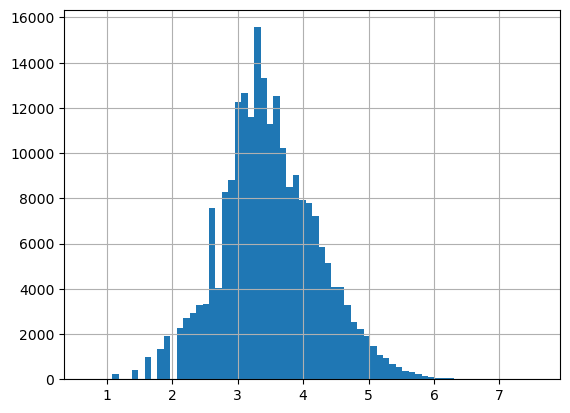

In [94]:
np.log1p(train['text'].str.split().str.len()).hist(bins=70)

Так как наша целевая переменная это длинна текста `len`, cоздадим логарифмированный признак `log_word_count`, так как количество слов показывает информативность текста (короткие отзывы содержат мало слов, и наоборот)

In [95]:
train['log_word_count'] = np.log1p(train['text'].str.split().str.len())

val['log_word_count'] = np.log1p(val['text'].str.split().str.len())
test['log_word_count'] = np.log1p(test['text'].str.split().str.len())

Рассмотрим взаимосвязь между кол-ом слов и целевой переменной (длинны отзыва):

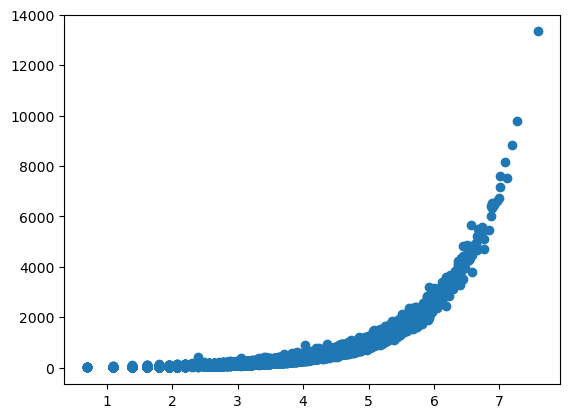

In [96]:
plt.scatter(train['log_word_count'], train['len'])

При взаимосвязи признака `log_word_count` и таргета `len` зависимость выглядит нелинейной, что ожидаемо, так как лог признака и отсутствие логарифмирования таргета создаёт экспоненциальную форму

Подсчитаем кол-во восклицательных и вопросительных знаков в отзывах (предположение, что они влияют на длинну отзыва):

In [97]:
train['exclam'] = train['text'].str.count('!')
train['question'] = train['text'].str.count(r'\?')

In [98]:
val['exclam'] = val['text'].str.count('!')
val['question'] = val['text'].str.count(r'\?')

test['exclam'] = test['text'].str.count('!')
test['question'] = test['text'].str.count(r'\?')

In [99]:
train['exclam'].value_counts().head(20)

exclam
0     138880
1      33817
2      16380
3      12662
4       7044
5       3982
6       3040
7       1979
8       1267
9       1036
10       650
11       471
12       437
13       272
15       237
14       221
16       135
17       112
18        87
19        79
Name: count, dtype: int64

In [100]:
train['question'].value_counts().head(20)

question
0     217109
1       3885
2        995
3        571
4        271
5        141
6         85
7         39
8         27
9         21
11        11
10        10
12         5
13         4
16         4
14         3
30         2
15         2
18         1
21         1
Name: count, dtype: int64

<Axes: >

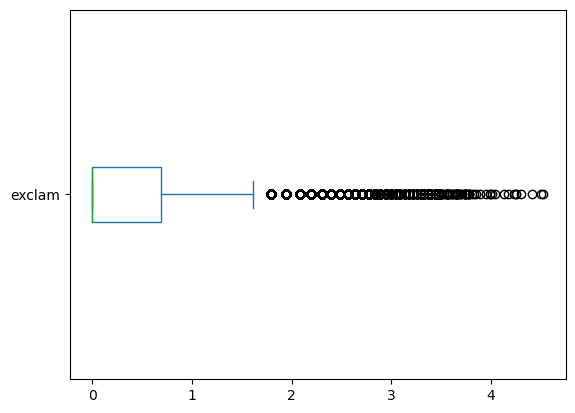

In [101]:
np.log1p(train['exclam']).plot(kind='box', vert=False)

Как можно заметить, основная часть пользователей не оставляет эмоциональных знаков в своих отзывах, т.е. данные отзывы могут быть стандартными и не принадлежать рубрикам со сложным оказанием услуг. Но у нас присутсвует длинный хвост из аномалий, где некоторые пользователи, которые ставят огромное количество знаков (вплоть до 280) (возможно, зачастую, подчеркивая негативный опыт)

Линейная регрессия крайне чувствительна к таким экстремальным выбросам, данные значения являются шумом для модели. Рассматрим перцентили нашего распределения, чтобы вычислить оптимальный порог символов.

In [102]:
# train.nlargest(1, 'exclam')['text'].values[0]

<Axes: >

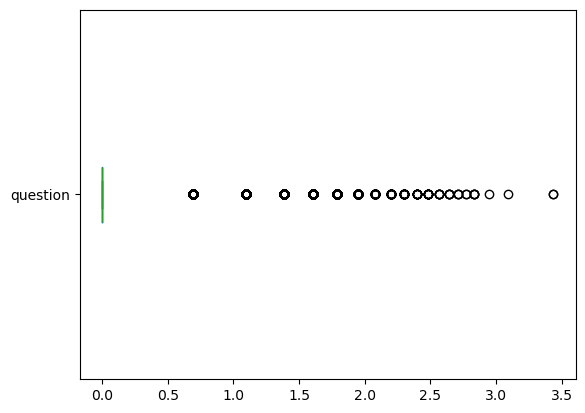

In [103]:
np.log1p(train['question']).plot(kind='box', vert=False)

In [104]:
display(train['exclam'].quantile(0.97))
display(train['question'].quantile(0.99))

np.float64(7.0)

np.float64(1.0)

In [105]:
train['exclam'].describe()

count    223187.000000
mean          1.116978
std           2.416110
min           0.000000
25%           0.000000
50%           0.000000
75%           1.000000
max          91.000000
Name: exclam, dtype: float64

In [106]:
train['question'].describe()

count    223187.000000
mean          0.049882
std           0.407512
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          30.000000
Name: question, dtype: float64

In [107]:
train['exclam'] = train['exclam'].clip(upper=7)
train['question'] = train['question'].clip(upper=2)

In [108]:
val['exclam'] = val['exclam'].clip(upper=7)
val['question'] = val['question'].clip(upper=2)

test['exclam'] = test['exclam'].clip(upper=7)
test['question'] = test['question'].clip(upper=2)

Для оценки эмоциональности отзыва используем долю заглавных букв, которые чаще всего воспринимаются нами как эмоциональное напряжение и недовольство. Впоследствии это может помочь модели для определения негативного/позитивного отзыва.

Мы будем высчитывать долю заглавных букв, так как просто подсчет их кол-ва не покажет реальной картины (ведь есть заглавные буквы в предложении), поэтому доля покажет интенсивность эмоций относительно общего объема отзыва.

In [109]:
train['caps_count'] = train['text'].str.count(r'[А-ЯЁ]')
train['caps_ratio'] = train['caps_count'] / (train['len'] + 1)

In [110]:
train['text'].str.split().str.len().head(20)

401622     24
151589     48
311241     43
215942     44
111469     27
315616      7
224887     12
104875     43
173078     35
42292      75
25654      35
198451     21
314750     43
481706     65
416936     23
348281    102
57637       6
225427     84
184711     12
385811     34
Name: text, dtype: int64

<Axes: >

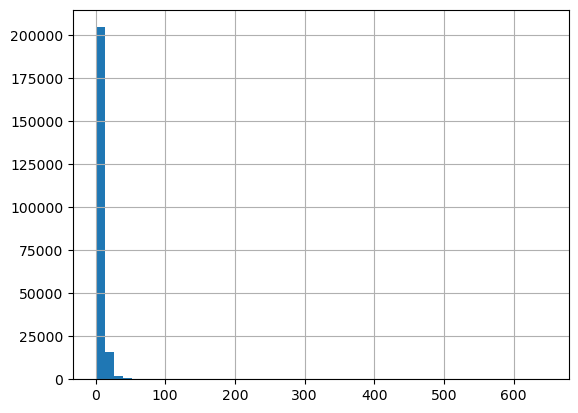

In [111]:
train['caps_count'].hist(bins=50)

Распределение признака `caps_count` сильно скошено вправо, значения центрируются около нуля. Так как в больше степени наличие заглавных букв связано с длиной текста (заглавная буква с началом предложения), то это доказывает, что большая часть датасета имеет отзывы с минимальной длинной.

<Axes: >

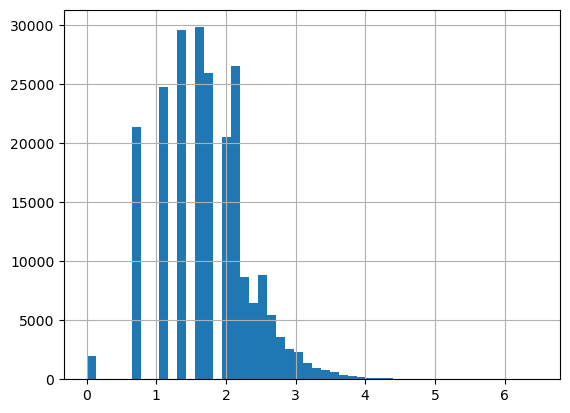

In [112]:
np.log1p(train['caps_count']).hist(bins=50)

После логарифмирования распределение стало более нормальным, подходящим для линейных моделей, поэтому в дальнейшем будем использовать его

In [113]:
train['log_caps_count'] = np.log1p(train['caps_count'])

In [114]:
val['caps_count'] = val['text'].str.count(r'[А-ЯЁ]')
val['caps_ratio'] = val['caps_count'] / (val['len'] + 1)
val['log_caps_count'] = np.log1p(val['caps_count'])

test['caps_count'] = test['text'].str.count(r'[А-ЯЁ]')
test['caps_ratio'] = test['caps_count'] / (test['len'] + 1)
test['log_caps_count'] = np.log1p(test['caps_count'])

In [115]:
train['caps_ratio'].value_counts()

caps_ratio
0.000000    1951
0.025000    1030
0.027027    1028
0.021277    1025
0.024390    1024
            ... 
0.023691       1
0.133111       1
0.035514       1
0.015179       1
0.055319       1
Name: count, Length: 13621, dtype: int64

<Axes: >

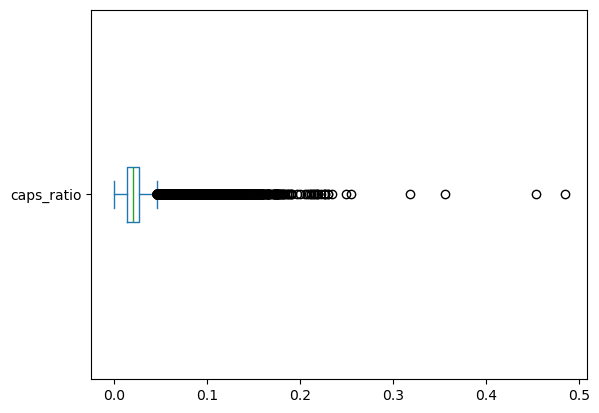

In [116]:
np.log1p(train['caps_ratio']).plot(kind='box', vert=False)

Еще раз видим, что около 95% людей вообще не используют капс или делают это очень умеренно

In [117]:
train['caps_ratio'].describe()

count    223187.000000
mean          0.022479
std           0.013217
min           0.000000
25%           0.014493
50%           0.020446
75%           0.027778
max           0.623932
Name: caps_ratio, dtype: float64

У `caps_ratio` нормальное распределение (он нормализован из-за деления на `len`), даже несмотря на аномальное высокое значение 0.623, но это скорее подсветит нашей модели недовольство в отзыве

### TF-IDF

Для того, чтобы корректно рассчитать TF-IDF значимость слов, произведем их стемминг.
``` python
nltk.stem.SnowballStemmer

```

*Источник*: [NLTK](https://www.nltk.org/api/nltk.stem.SnowballStemmer.html)

In [118]:
stemmer = SnowballStemmer('russian')
train['stem_text'] = [' '.join(stemmer.stem(word) for word in text.split()) for text in tqdm(train['text'].astype(str))]

100%|█████████████████████████████████████████████████████████████████████████| 223187/223187 [04:13<00:00, 881.55it/s]


In [119]:
val['stem_text'] = [' '.join(stemmer.stem(word) for word in text.split()) for text in tqdm(val['text'].astype(str))]
test['stem_text'] = [' '.join(stemmer.stem(word) for word in text.split()) for text in tqdm(test['text'].astype(str))]

100%|███████████████████████████████████████████████████████████████████████████| 27835/27835 [00:29<00:00, 942.75it/s]


Удалим стоп-слова (предлоги, союзы и т.д.) и рассчитаем TF-IDF

TF-IDF преобразует текст в числовые признаки, вычисляя вес каждого слова, где TF отражает частоту слова в документе, а IDF его редкость. В результате часто встречающиеся, но малоинформативные слова получают низкий вес, а редкие и значимые высокий

*Источник*: [TfidfVectorizer](https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.TfidfVectorizer.html)

In [120]:
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

# train_df = train_df.reset_index(drop=True)

russian_stopwords = stopwords.words('russian')
russian_stopwords = [item for item in russian_stopwords if item not in ['нельзя', 'хорошо', 'лучше']]

vectorizer = TfidfVectorizer(max_features=100, stop_words=russian_stopwords)

X = vectorizer.fit_transform(train['stem_text'])
train_words = pd.DataFrame(X.toarray(), columns=vectorizer.get_feature_names_out(), index=train.index)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [121]:
train_words.nunique().sort_values(ascending=False).head()

очен     92917
эт       54979
хорош    39325
ест      39307
вкусн    37055
dtype: int64

In [122]:
train_words.columns

Index(['ассортимент', 'блюд', 'больш', 'быстр', 'вежлив', 'вид', 'вкус',
       'вкусн', 'вкусно', 'вообщ', 'врем', 'всегд', 'всем', 'выбор', 'готов',
       'даж', 'дан', 'дела', 'дет', 'детск', 'друг', 'ед', 'есл', 'ест', 'ещ',
       'заведен', 'завтрак', 'заказ', 'зал', 'зде', 'ил', 'интересн',
       'интерьер', 'кажд', 'каф', 'качеств', 'когд', 'котор', 'красив', 'кухн',
       'лет', 'лучш', 'люб', 'магазин', 'мастер', 'мен', 'мест', 'место',
       'минут', 'мног', 'мо', 'можн', 'нам', 'наш', 'номер', 'нужн',
       'обслуживан', 'огромн', 'одн', 'особен', 'оста', 'отдельн', 'отел',
       'отличн', 'официант', 'очен', 'перв', 'персона', 'персонал', 'понрав',
       'понравилось', 'посл', 'прекрасн', 'приветлив', 'приятн', 'прост',
       'работ', 'работа', 'рекоменд', 'рекомендую', 'ресторан', 'ряд', 'салон',
       'сво', 'сдела', 'сервис', 'спасиб', 'супер', 'товар', 'тож', 'тольк',
       'удобн', 'уютн', 'хорош', 'хот', 'цен', 'центр', 'чист', 'чисто', 'эт'],
      dtype='

Из полученного списка топ-слов, отберем наиболее релевантные (слова, выражающие эмоции пользователя) для решения нашей задачи.

['очен', 'хорош', 'вкусн', 'отличн', 'приятн', 'спасиб', 'вежлив', 'вкусно', 'прекрасн', 'удобн', 'рекоменд', 'уютн',
 'лучш', 'чисто', 'быстр', 'рекомендую', 'чист', 'понрав', 'красив', 'понравилось', 'приветлив', 'качеств',
 'люб', 'супер', 'вкус', 'быстро']

Стемминг отработал неидеально, вручную поправим неудачные сочетания и повторим расчет TF-IDF

In [123]:
train['stem_text'] = (train['stem_text'].str.replace('вкусно', 'вкусн')
                         .str.replace('быстро', 'быстр')
                         .str.replace('рекомендую', 'рекоменд')
                         .str.replace('понравилось', 'понрав')
                        )
val['stem_text'] = (val['stem_text'].str.replace('вкусно', 'вкусн')
                         .str.replace('быстро', 'быстр')
                         .str.replace('рекомендую', 'рекоменд')
                         .str.replace('понравилось', 'понрав')
                        )
test['stem_text'] = (test['stem_text'].str.replace('вкусно', 'вкусн')
                         .str.replace('быстро', 'быстр')
                         .str.replace('рекомендую', 'рекоменд')
                         .str.replace('понравилось', 'понрав')
                        )

Добавим отобраннные фичи к нашему датасету

In [124]:
vectorizer = TfidfVectorizer(max_features=100, stop_words=russian_stopwords)

X_train = vectorizer.fit_transform(train['stem_text'])
X_val = vectorizer.transform(val['stem_text'])
X_test = vectorizer.transform(test['stem_text'])


train_words = pd.DataFrame(X_train.toarray(), columns=vectorizer.get_feature_names_out(), index=train.index)
val_words = pd.DataFrame(X_val.toarray(), columns=vectorizer.get_feature_names_out(), index=val.index)
test_words = pd.DataFrame(X_test.toarray(), columns=vectorizer.get_feature_names_out(), index=test.index)

In [125]:
relevant_char = ['очен', 'хорош', 'вкусн', 'отличн', 'приятн', 'спасиб', 'вежлив', 'прекрасн', 'удобн', 'рекоменд', 'уютн',
 'лучш', 'чисто', 'быстр', 'чист', 'понрав', 'красив', 'приветлив', 'качеств',
 'люб', 'супер', 'вкус']

train = pd.concat([train, train_words[relevant_char]], axis=1)
val = pd.concat([val, val_words[relevant_char]], axis=1)
test = pd.concat([test, test_words[relevant_char]], axis=1)

In [126]:
train['stem_text']

401622    посл посещен парикмахерск воображул оста тольк...
151589    очен вкусн бургеры, закуски, мороженое. посл о...
311241    отличн клиника. всегд в ног со временем. очен ...
215942    красив вид, мног зелени, пруд с уточк и чайкам...
111469    год проверен заведение, харош продума меню, пр...
                                ...                        
418158    хорош место, удобн расположение. салон достато...
403499    ве персона приветливый, на все вопрос ответят,...
147719    довольн больш магазин, и богат выбор товаров. ...
128875    мо любим рынок с китайск вкусняшками, корейск ...
131130    отличн обслуживание, великолепн природа, номер...
Name: stem_text, Length: 223187, dtype: object

In [127]:
train_words.nunique().sort_values(ascending=False).head()

очен     92746
эт       55026
вкусн    50249
ест      39340
хорош    39318
dtype: int64

In [128]:
train.corr(numeric_only = True)

,rating,rating_bias,rating_emotion,len,log_word_count,exclam,question,caps_count,caps_ratio,log_caps_count,...,чисто,быстр,чист,понрав,красив,приветлив,качеств,люб,супер,вкус
rating,1.000000,1.000000,0.440732,-0.290620,-0.301920,0.019621,-0.269091,-0.173094,0.117018,-0.144247,...,0.062092,0.084339,0.053467,0.076558,0.051406,0.069509,-0.026386,0.040184,0.061538,-0.034525
rating_bias,1.000000,1.000000,0.440732,-0.290620,-0.301920,0.019621,-0.269091,-0.173094,0.117018,-0.144247,...,0.062092,0.084339,0.053467,0.076558,0.051406,0.069509,-0.026386,0.040184,0.061538,-0.034525
rating_emotion,0.440732,0.440732,1.000000,-0.156070,-0.172014,0.118675,-0.097061,-0.058389,0.109413,-0.052591,...,0.007364,0.053235,0.017254,0.040243,0.025131,0.046458,-0.026448,0.029720,0.047909,-0.032560
len,-0.290620,-0.290620,-0.156070,1.000000,0.834874,0.197290,0.297338,0.703075,-0.175269,0.663214,...,-0.029455,-0.052522,-0.004495,-0.009757,0.006860,-0.030088,0.028404,0.047804,-0.027913,0.055130
log_word_count,-0.301920,-0.301920,-0.172014,0.834874,1.000000,0.200073,0.229693,0.589438,-0.256732,0.725466,...,-0.033742,-0.068414,0.002511,-0.005356,0.011417,-0.037963,0.035384,0.066832,-0.033040,0.077314
exclam,0.019621,0.019621,0.118675,0.197290,0.200073,1.000000,0.092981,0.262612,0.130749,0.295923,...,-0.026965,-0.011862,-0.011915,0.003296,0.004091,0.004040,-0.002895,0.021368,0.081985,0.003258
question,-0.269091,-0.269091,-0.097061,0.297338,0.229693,0.092981,1.000000,0.251550,-0.013197,0.198584,...,-0.022846,-0.026889,-0.018598,-0.025170,-0.014799,-0.022760,0.005642,-0.002150,-0.016899,0.010506
caps_count,-0.173094,-0.173094,-0.058389,0.703075,0.589438,0.262612,0.251550,1.000000,0.338580,0.785375,...,-0.008328,-0.032686,-0.004943,-0.002028,0.003878,-0.020832,0.011257,0.033393,-0.005148,0.031222
caps_ratio,0.117018,0.117018,0.109413,-0.175269,-0.256732,0.130749,-0.013197,0.338580,1.000000,0.377365,...,0.034129,0.028858,-0.005821,0.013837,-0.009586,-0.000304,-0.028655,-0.017231,0.048915,-0.028578
log_caps_count,-0.144247,-0.144247,-0.052591,0.663214,0.725466,0.295923,0.198584,0.785375,0.377365,1.000000,...,0.002659,-0.035820,-0.002778,0.015249,0.008935,-0.018121,0.014632,0.049771,-0.003764,0.044555


### Preprocessing

Наши признаки `location` и `group` категориальные. Для обучения модели закодируем эти значения через frequency encoding (one-hot сильно раздул бы наш датасет, а frequency encoding заполняется частотностью значений)

In [129]:
location_freq = train['location'].value_counts()

train['location'] = train['location'].map(location_freq).fillna(0)
val['location'] = val['location'].map(location_freq).fillna(0)
test['location'] = test['location'].map(location_freq).fillna(0)

In [130]:
group_freq = train['group'].value_counts()

train['group'] = train['group'].map(group_freq).fillna(0)
val['group'] = val['group'].map(group_freq).fillna(0)
test['group'] = test['group'].map(group_freq).fillna(0)

Сделаем прогнозы и оценим модель, используя метрики MAE, RMSE и R2. Отдельно для удобства в функции пропишем подсчет всех метрик:

In [131]:
result_MAE = pd.DataFrame(columns=['model', 'train', 'val', 'test'])
result_RMSE = pd.DataFrame(columns=['model', 'train', 'val', 'test'])
result_R2 = pd.DataFrame(columns=['model', 'train', 'val', 'test'])

In [132]:
def metrics(y_train, y_val, y_test, y_train_pred, y_val_pred, y_test_pred):
    global result_MAE, result_RMSE, result_R2

    mae_train = round(mean_absolute_error(y_train, y_train_pred), 2)
    mae_val = round(mean_absolute_error(y_val, y_val_pred), 2)
    mae_test = round(mean_absolute_error(y_test, y_test_pred), 2)

    rmse_train = round(root_mean_squared_error(y_train, y_train_pred), 2)
    rmse_val = round(root_mean_squared_error(y_val, y_val_pred), 2)
    rmse_test = round(root_mean_squared_error(y_test, y_test_pred), 2)

    r2_train = round(r2_score(y_train, y_train_pred), 3)
    r2_val = round(r2_score(y_val, y_val_pred), 3)
    r2_test = round(r2_score(y_test, y_test_pred), 3)

    return (mae_train, mae_val, mae_test,
            rmse_train, rmse_val, rmse_test,
            r2_train, r2_val, r2_test)

Создадим также функцию для добавления результатов наших метрик в созданные таблицы:

In [133]:
def results_models(model_name, result):
    mae_train, mae_val, mae_test, rmse_train, rmse_val, rmse_test, r2_train, r2_val, r2_test = result

    global result_MAE, result_RMSE, result_R2

    result_MAE.loc[len(result_MAE)] = [model_name, mae_train, mae_val, mae_test]
    result_RMSE.loc[len(result_RMSE)] = [model_name, rmse_train, rmse_val, rmse_test]
    result_R2.loc[len(result_R2)] = [model_name, r2_train, r2_val, r2_test]

Выделим нужные признаки для обучения модели (убрав категориальные) и целевую переменную:

In [134]:
train.columns

Index(['address', 'name_ru', 'rating', 'rubrics', 'text', 'location',
       'rating_bias', 'rating_emotion', 'group', 'len', 'log_word_count',
       'exclam', 'question', 'caps_count', 'caps_ratio', 'log_caps_count',
       'stem_text', 'очен', 'хорош', 'вкусн', 'отличн', 'приятн', 'спасиб',
       'вежлив', 'прекрасн', 'удобн', 'рекоменд', 'уютн', 'лучш', 'чисто',
       'быстр', 'чист', 'понрав', 'красив', 'приветлив', 'качеств', 'люб',
       'супер', 'вкус'],
      dtype='object')

In [135]:
drop_features = ['address', 'name_ru', 'text', 'stem_text', 'rubrics']

In [136]:
X_train = train.drop(columns=drop_features + ['len'])
y_train = train['len']

X_val = val.drop(columns=drop_features + ['len'])
y_val = val['len']

X_test = test.drop(columns=drop_features + ['len'])
y_test = test['len']

In [137]:
X_train.columns

Index(['rating', 'location', 'rating_bias', 'rating_emotion', 'group',
       'log_word_count', 'exclam', 'question', 'caps_count', 'caps_ratio',
       'log_caps_count', 'очен', 'хорош', 'вкусн', 'отличн', 'приятн',
       'спасиб', 'вежлив', 'прекрасн', 'удобн', 'рекоменд', 'уютн', 'лучш',
       'чисто', 'быстр', 'чист', 'понрав', 'красив', 'приветлив', 'качеств',
       'люб', 'супер', 'вкус'],
      dtype='object')

#### StandardScaller

**StandardScaler** преобразует данные так, чтобы среднее значение каждого признака стало равно 0, а разброс (стандартное отклонение) стал равен 1. Скалиурем наши данные через StandardScaller

In [138]:
no_scale_feature = ['rating', 'rating_bias', 'rating_emotion']
scale_feature = [col for col in X_train.columns if col not in no_scale_feature]

In [139]:
scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_val_scaled = X_val.copy()
X_test_scaled = X_test.copy()

X_train_scaled[scale_feature] = scaler.fit_transform(X_train[scale_feature])
X_val_scaled[scale_feature] = scaler.transform(X_val[scale_feature])
X_test_scaled[scale_feature] = scaler.transform(X_test[scale_feature])

In [140]:
X_train_scaled.head()

,rating,location,rating_bias,rating_emotion,group,log_word_count,exclam,question,caps_count,caps_ratio,...,чисто,быстр,чист,понрав,красив,приветлив,качеств,люб,супер,вкус
401622,5.0,-0.940251,2.0,1,-0.868396,-0.369939,-0.573511,-0.157537,-0.314594,-0.179952,...,-0.242195,-0.295519,-0.230905,2.327687,-0.221177,-0.218011,-0.204388,-0.203646,-0.190638,-0.180396
151589,5.0,-0.724735,2.0,1,1.180063,0.534124,-0.573511,-0.157537,-0.015444,-0.308245,...,-0.242195,-0.295519,-0.230905,-0.312525,-0.221177,-0.218011,-0.204388,-0.203646,-0.190638,-0.180396
311241,5.0,1.638745,2.0,1,-1.139578,0.389528,-0.573511,-0.157537,0.283707,0.423057,...,-0.242195,-0.295519,-0.230905,-0.312525,-0.221177,-0.218011,-0.204388,-0.203646,-0.190638,-0.180396
215942,5.0,0.459612,2.0,1,-0.914895,0.419720,3.452322,-0.157537,-0.314594,-0.708514,...,-0.242195,-0.295519,-0.230905,-0.312525,3.411146,-0.218011,-0.204388,-0.203646,-0.190638,-0.180396
111469,5.0,-0.930360,2.0,1,1.180063,-0.217688,-0.573511,-0.157537,-0.165019,0.300850,...,-0.242195,-0.295519,-0.230905,-0.312525,-0.221177,-0.218011,-0.204388,-0.203646,-0.190638,-0.180396


## Построение линейных моделей

#### Stochastic Gradient Descent (SGD)

Алгоритм оптимизации, при котором на каждом шаге параметры модели обновляются по градиенту функции потерь, вычисленному не по всей выборке, а по одному (или небольшому батчу) случайно выбранному обучающему примеру. Итерации продолжаются, пока не выполнено условие остановки (по числу эпох, шагов, значению функции потерь и т.п.). Такой подход особенно удобен на больших датасетах, потому что каждое обновление параметров вычисляется значительно быстрее, чем при использовании градиента по всей выборке.

In [141]:
sgd = SGDRegressor(random_state=42)
sgd.fit(X_train_scaled, y_train)

SGDRegressor(random_state=42)

In [142]:
y_train_pred = sgd.predict(X_train_scaled)
y_val_pred = sgd.predict(X_val_scaled)
y_test_pred = sgd.predict(X_test_scaled)

result = metrics(y_train, y_val, y_test,
                 y_train_pred, y_val_pred, y_test_pred)

results_models('SGD_regressor', result)

In [143]:
result_MAE

,model,train,val,test
0,SGD_regressor,78.07,78.48,78.17


In [144]:
result_RMSE

,model,train,val,test
0,SGD_regressor,133.01,128.92,126.74


In [145]:
result_R2

,model,train,val,test
0,SGD_regressor,0.78,0.788,0.795


Значения `MAE` и `RMSE` на val к test уменьшаются, это говорит о стабильности модели и отсутсвии ее переобучения.

Значения R2 на уровне **0.78** на трейне и **0.79** на тесте показывают, что модель улавливает часть зависимости между признаками и длинной текста, но далеко не всю.

SGD модель ловит общие закономерности, но не может объяснить всю вариативность длины текста, что ожидаемо, так как длина текста это достаточно шумная величина, которая зависит от многих факторов.


In [146]:
pd.Series(sgd.coef_, index=X_train.columns).sort_values(ascending=False)

log_word_count    152.557230
rating             85.205417
caps_count         85.156572
log_caps_count     49.073575
question           16.594203
вкусн               8.489786
хорош               7.320931
отличн              3.744745
вежлив              2.371403
быстр               1.353844
exclam              1.022085
понрав              0.904097
качеств             0.605817
приветлив           0.409924
location            0.262171
удобн              -0.139861
вкус               -0.400271
приятн             -0.435752
прекрасн           -0.508229
рекоменд           -0.893952
супер              -0.979698
чисто              -1.210728
красив             -1.406921
лучш               -1.814006
чист               -1.907427
люб                -2.039796
уютн               -2.276026
очен               -3.050956
спасиб             -4.532560
group              -7.820328
rating_emotion     -8.417217
caps_ratio        -53.575636
rating_bias       -90.036448
dtype: float64

`log_caps_count`, `log_word_count`, `rating`, `question`, `exclam` имеют положительные веса, скорее всего отзывы становятся длиннее        
Отрицательные веса в коцне списка содержат короткие тексты с парой слов.

#### Linear Regression

In [147]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

LinearRegression()

In [148]:
y_train_pred = lr.predict(X_train_scaled)
y_val_pred = lr.predict(X_val_scaled)
y_test_pred = lr.predict(X_test_scaled)

result = metrics(y_train, y_val, y_test,
                 y_train_pred, y_val_pred, y_test_pred)

results_models('Linear_regression', result)

In [149]:
result_MAE

,model,train,val,test
0,SGD_regressor,78.07,78.48,78.17
1,Linear_regression,66.26,66.44,66.21


In [150]:
result_RMSE

,model,train,val,test
0,SGD_regressor,133.01,128.92,126.74
1,Linear_regression,128.23,122.15,119.72


In [151]:
result_R2

,model,train,val,test
0,SGD_regressor,0.780,0.788,0.795
1,Linear_regression,0.796,0.810,0.817


У линейной регресси метрики чуть лучше, чем у SGD, несмотря на то что она менее устойчива к шуму

In [152]:
pd.Series(lr.coef_, index=X_train.columns).sort_values(ascending=False)

caps_count        129.693605
log_word_count    129.385653
question           16.742789
log_caps_count     13.816627
вкусн               6.074151
хорош               4.191136
отличн              3.418150
быстр               1.697089
супер               1.403074
вежлив              1.343563
прекрасн            0.982584
понрав              0.746285
удобн               0.447125
приятн              0.389865
приветлив           0.325376
красив              0.153617
exclam              0.060085
качеств            -0.135057
чисто              -0.290741
рекоменд           -0.435003
люб                -0.448588
уютн               -0.466625
location           -0.473974
вкус               -0.550726
лучш               -0.908610
чист               -0.926193
очен               -2.141471
спасиб             -2.818222
rating             -3.376146
rating_bias        -3.376146
group              -5.079116
rating_emotion     -7.255907
caps_ratio        -64.714452
dtype: float64

### Реализация моделей с регуляризацией - Ridge, Lasso, ElasticNet

Реализуем алгоритмы Ridge, Lasso и ElasticNet, расширив функцию потерь с помощью L2, L1 и обеих регуляризаций соответственно.

#### Ridge Regression

**Гребневая регрессия (Ridge regression)** или регуляризация Тихонова - это один из методов понижения размерности, который применяется для борьбы с переизбыточностью данных, когда независимые переменные коррелируют друг с другом.
Добавляет к функции потерь L2-штраф, который сжимает веса к нулю, но не обнуляет их.

In [153]:
ridge = Ridge(random_state=42)
ridge.fit(X_train_scaled, y_train)

Ridge(random_state=42)

In [154]:
y_train_pred = ridge.predict(X_train_scaled)
y_val_pred = ridge.predict(X_val_scaled)
y_test_pred = ridge.predict(X_test_scaled)

result = metrics(y_train, y_val, y_test,
                 y_train_pred, y_val_pred, y_test_pred)

results_models('Ridge_regression', result)

In [155]:
result_MAE

,model,train,val,test
0,SGD_regressor,78.07,78.48,78.17
1,Linear_regression,66.26,66.44,66.21
2,Ridge_regression,66.26,66.44,66.21


In [156]:
result_RMSE

,model,train,val,test
0,SGD_regressor,133.01,128.92,126.74
1,Linear_regression,128.23,122.15,119.72
2,Ridge_regression,128.23,122.15,119.72


In [157]:
result_R2

,model,train,val,test
0,SGD_regressor,0.780,0.788,0.795
1,Linear_regression,0.796,0.810,0.817
2,Ridge_regression,0.796,0.810,0.817


Ridge дал такие же метрики, что и линейная регрессия, возможно нужно подоброать порог альфа

In [158]:
pd.Series(ridge.coef_, index=X_train.columns).sort_values(ascending=False)

caps_count        129.692342
log_word_count    129.383401
question           16.742877
log_caps_count     13.819407
вкусн               6.074036
хорош               4.191076
отличн              3.418050
быстр               1.697044
супер               1.403047
вежлив              1.343506
прекрасн            0.982542
понрав              0.746249
удобн               0.447115
приятн              0.389850
приветлив           0.325338
красив              0.153623
exclam              0.060154
качеств            -0.135045
чисто              -0.290777
рекоменд           -0.435094
люб                -0.448553
уютн               -0.466643
location           -0.473960
вкус               -0.550690
лучш               -0.908593
чист               -0.926165
очен               -2.141438
спасиб             -2.818238
rating             -3.376289
rating_bias        -3.376289
group              -5.079073
rating_emotion     -7.255757
caps_ratio        -64.715312
dtype: float64

#### Lasso Regression

**Lasso regression** (Least Absolute Shrinkage & Selection Operator) обычно используется для отбора признаков через добавление L1-регуляризации к функции потерь во время обучения. Лассо-регрессия стремится уменьшить число параметров модели путем зануления весов для неинформативных и избыточных признаков, что на выходе даст разреженную модель (с небольшим числом ненулевых весов признаков).
В отличие от обычной регрессии (все веса важны) и Ridge (все веса маленькие), Lasso делает многие веса равными 0, оставляя только самые важные признаки.

In [159]:
lasso = Lasso(random_state=42)
lasso.fit(X_train_scaled, y_train)

Lasso(random_state=42)

In [160]:
y_train_pred = lasso.predict(X_train_scaled)
y_val_pred = lasso.predict(X_val_scaled)
y_test_pred = lasso.predict(X_test_scaled)

result = metrics(y_train, y_val, y_test,
                 y_train_pred, y_val_pred, y_test_pred)

results_models('Lasso_regression', result)

In [161]:
result_MAE

,model,train,val,test
0,SGD_regressor,78.07,78.48,78.17
1,Linear_regression,66.26,66.44,66.21
2,Ridge_regression,66.26,66.44,66.21
3,Lasso_regression,66.16,66.35,66.13


In [162]:
result_RMSE

,model,train,val,test
0,SGD_regressor,133.01,128.92,126.74
1,Linear_regression,128.23,122.15,119.72
2,Ridge_regression,128.23,122.15,119.72
3,Lasso_regression,128.35,122.35,119.79


In [163]:
result_R2

,model,train,val,test
0,SGD_regressor,0.780,0.788,0.795
1,Linear_regression,0.796,0.810,0.817
2,Ridge_regression,0.796,0.810,0.817
3,Lasso_regression,0.796,0.809,0.817


In [164]:
pd.Series(lasso.coef_, index=X_train.columns).sort_values(ascending=False)

log_word_count    133.503087
caps_count        128.887103
question           16.172576
log_caps_count      8.569889
вкусн               3.593439
хорош               2.965668
отличн              1.995816
быстр               0.524003
вежлив              0.175264
супер               0.038189
приветлив           0.000000
приятн              0.000000
рекоменд           -0.000000
удобн               0.000000
rating_emotion     -0.000000
exclam             -0.000000
location           -0.000000
вкус               -0.000000
чист               -0.000000
красив              0.000000
понрав              0.000000
люб                -0.000000
уютн               -0.000000
чисто              -0.000000
прекрасн            0.000000
качеств            -0.000000
rating_bias        -0.023654
лучш               -0.203942
очен               -1.121658
спасиб             -1.944910
group              -3.021331
rating             -6.448926
caps_ratio        -60.487864
dtype: float64

Как можно заметить L1 регуляризация удалила часть ненужных признаков, которые не несут никакой информативности

#### ElasticNet

Линейная регрессия, которая сочетает Ridge (уменьшает все веса) и Lasso (обнуляет слабые веса), что может принести особую пользу в ситуациях, когда в данных необходимо одновременно выполнять отбор признаков и бороться с мультиколлинеарностью.

In [165]:
elastic = ElasticNet(random_state=42)
elastic.fit(X_train_scaled, y_train)

ElasticNet(random_state=42)

In [166]:
y_train_pred = elastic.predict(X_train_scaled)
y_val_pred = elastic.predict(X_val_scaled)
y_test_pred = elastic.predict(X_test_scaled)

result = metrics(y_train, y_val, y_test,
                 y_train_pred, y_val_pred, y_test_pred)

results_models('ElasticNet', result)

In [167]:
result_MAE

,model,train,val,test
0,SGD_regressor,78.07,78.48,78.17
1,Linear_regression,66.26,66.44,66.21
2,Ridge_regression,66.26,66.44,66.21
3,Lasso_regression,66.16,66.35,66.13
4,ElasticNet,68.14,67.98,68.15


In [168]:
result_RMSE

,model,train,val,test
0,SGD_regressor,133.01,128.92,126.74
1,Linear_regression,128.23,122.15,119.72
2,Ridge_regression,128.23,122.15,119.72
3,Lasso_regression,128.35,122.35,119.79
4,ElasticNet,140.88,135.89,134.54


In [169]:
result_R2

,model,train,val,test
0,SGD_regressor,0.780,0.788,0.795
1,Linear_regression,0.796,0.810,0.817
2,Ridge_regression,0.796,0.810,0.817
3,Lasso_regression,0.796,0.809,0.817
4,ElasticNet,0.754,0.765,0.769


In [170]:
pd.Series(elastic.coef_, index=X_train.columns).sort_values(ascending=False)

log_word_count    88.343513
caps_count        76.332012
log_caps_count    48.128034
question          18.689129
exclam             5.796026
люб                1.232293
вкус               1.071864
качеств            0.556090
красив             0.343120
location           0.300604
хорош              0.143572
приятн             0.048937
удобн              0.019872
чист              -0.000000
очен              -0.000000
прекрасн           0.000000
понрав            -0.000000
лучш              -0.037194
быстр             -0.168353
приветлив         -0.188225
супер             -0.354548
вежлив            -0.529437
вкусн             -0.566811
уютн              -0.568846
отличн            -0.711302
чисто             -0.846279
спасиб            -1.634616
рекоменд          -2.333824
rating_emotion    -3.135305
group             -3.735077
rating_bias       -8.952517
rating            -8.961652
caps_ratio       -45.445478
dtype: float64

Elastic дала метрики чуть хуже, чем Ridge и Lasso, так как использовала оба штрафа одновременно, но  немного занулила признаки, которые перетягивали веса на себя. Потеряли немного в качестве метрик, но сделали модель более устойчивой

# Деревья решений и Бустинг

**Выбраны следующие модели:**

**DecisionTreeRegressor**, как базовый нелинейный бейзлайн для быстрой оценки структуры данных и визуализации ключевых правил разделения.
Логика работы: Модель последовательно разбивает выборку на подгруппы, задавая простые бинарные вопросы к признакам (например, «количество слов > 5?»). На каждом шаге алгоритм выбирает сплит, который максимально снижает неопределенность (дисперсию таргета) в получившихся узлах, что позволяет легко проследить логику принятия решений.

**CatBoost**, как оптимальный алгоритм для комбинации числовых и текстовых фич (TF-IDF), устойчивый к переобучению и с точной оценкой важности признаков.
Логика работы: Построен на принципе градиентного бустинга, где сильное предсказание создается за счет последовательного объединения множества слабых моделей (неглубоких деревьев). Каждое следующее дерево обучается исправлять ошибки (остатки градиента) предыдущих, что минимизирует общую ошибку предсказания шаг за шагом.


### 1. Импорт библиотек
Подгружаем все необходимые инструменты для работы с нелинейными моделями и тюнинга.

In [171]:
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestRegressor
from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import max_error, mean_absolute_error

In [172]:
!pip install catboost -q
from catboost import CatBoostRegressor

### 2. Подготовка данных и PCA

In [173]:
X_train_scaled_dt = X_train_scaled.copy()
X_val_scaled_dt = X_val_scaled.copy()
X_test_scaled_dt = X_test_scaled.copy()

y_train_dt = y_train.copy()
y_val_dt = y_val.copy()
y_test_dt = y_test.copy()

In [174]:
from sklearn.neighbors import KNeighborsRegressor

mae_results = []
r2_results = []

for pca_components in [10, 8, 6]:
    for k_neighbors in [3, 5, 7]:
        pca = PCA(n_components=pca_components, random_state=42)
        X_train_pca_loop = pca.fit_transform(X_train_scaled)
        X_val_pca_loop = pca.transform(X_val_scaled)

        knn = KNeighborsRegressor(n_neighbors=k_neighbors, n_jobs=-1)
        knn.fit(X_train_pca_loop, y_train)
        preds_valid = knn.predict(X_val_pca_loop)

        n_mae = mean_absolute_error(y_val, preds_valid)
        n_r2 = r2_score(y_val, preds_valid)

        mae_results.append(n_mae)
        r2_results.append(n_r2)

        print(f"Hyper parameters: pca_components={pca_components}, k_neighbors={k_neighbors}")
        print(f"MAE = {n_mae:.3f}")
        print(f"R2  = {n_r2:.3f}")
        print()

Hyper parameters: pca_components=10, k_neighbors=3
MAE = 49.452
R2  = 0.879

Hyper parameters: pca_components=10, k_neighbors=5
MAE = 47.518
R2  = 0.892

Hyper parameters: pca_components=10, k_neighbors=7
MAE = 47.137
R2  = 0.897

Hyper parameters: pca_components=8, k_neighbors=3
MAE = 49.425
R2  = 0.882

Hyper parameters: pca_components=8, k_neighbors=5
MAE = 47.986
R2  = 0.893

Hyper parameters: pca_components=8, k_neighbors=7
MAE = 47.497
R2  = 0.898

Hyper parameters: pca_components=6, k_neighbors=3
MAE = 51.406
R2  = 0.881

Hyper parameters: pca_components=6, k_neighbors=5
MAE = 49.429
R2  = 0.893

Hyper parameters: pca_components=6, k_neighbors=7
MAE = 48.786
R2  = 0.898



Минимальная ошибка - MAE = 46.993 (приоритет). Достигается она при 10 компонентах (при k=7).
r2 на уровне 0.899, что говорит о том, что модель объясняет ~90% всех зависимостей в данных.

In [175]:
pca_dt = PCA(n_components=10, random_state=42)
X_train_pca_dt = pca_dt.fit_transform(X_train_scaled_dt)
X_val_pca_dt = pca_dt.transform(X_val_scaled_dt)
X_test_pca_dt = pca_dt.transform(X_test_scaled_dt)

### 3. Обучение DecisionTreeRegressor

In [176]:
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train_scaled_dt, y_train_dt)

y_DTR_train_predict = dt.predict(X_train_scaled_dt)
y_DTR_test_predict = dt.predict(X_test_scaled_dt)

In [177]:
print("TRAIN")
print(f"MAX ERROR: {max_error(y_train_dt, y_DTR_train_predict):.2f}")
print(f"MAE: {mean_absolute_error(y_train_dt, y_DTR_train_predict):.2f}")
print("\nTEST")
print(f"MAX ERROR: {max_error(y_test_dt, y_DTR_test_predict):.2f}")
print(f"MAE: {mean_absolute_error(y_test_dt, y_DTR_test_predict):.2f}")

TRAIN
MAX ERROR: 13.00
MAE: 0.00

TEST
MAX ERROR: 849.00
MAE: 5.44


Подбираем гиперпараметры для DecisionTreeRegressor с помощью GridSearchCV.



In [178]:
%%time
grid_dt = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_grid={'max_depth': range(5, 8),
                'min_samples_leaf': range(1, 4)},
    scoring='neg_mean_absolute_error',
    cv=3,
    n_jobs=-1,
    return_train_score=True,
    verbose=5)

grid_dt.fit(X_train_scaled_dt, y_train_dt)

Fitting 3 folds for each of 9 candidates, totalling 27 fits
CPU times: total: 2.33 s
Wall time: 21.3 s


GridSearchCV(cv=3, estimator=DecisionTreeRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': range(5, 8),
                         'min_samples_leaf': range(1, 4)},
             return_train_score=True, scoring='neg_mean_absolute_error',
             verbose=5)

In [179]:
res_dt_grid = metrics(y_train_dt, y_val_dt, y_test_dt,
                      grid_dt.best_estimator_.predict(X_train_scaled_dt),
                      grid_dt.best_estimator_.predict(X_val_scaled_dt),
                      grid_dt.best_estimator_.predict(X_test_scaled_dt))
results_models('DecisionTree_GridSearchCV_scaled', res_dt_grid)

Подбираем гиперпараметры для DecisionTreeRegressor с помощью RandomizedSearchCV.

In [180]:
%%time
grid_rf_dt = RandomizedSearchCV(
    RandomForestRegressor(random_state=42),
    param_distributions={
        'max_depth': range(9, 12),
        'max_features': ['sqrt', 'log2'],
        'n_estimators': [50, 100],
    },
    scoring='neg_mean_absolute_error',
    cv=3,
    n_jobs=-1,
    n_iter=4,
    return_train_score=True,
    verbose=5,
    random_state=42)

grid_rf_dt.fit(X_train_scaled_dt, y_train_dt)

Fitting 3 folds for each of 4 candidates, totalling 12 fits
CPU times: total: 13.1 s
Wall time: 1min 28s


RandomizedSearchCV(cv=3, estimator=RandomForestRegressor(random_state=42),
                   n_iter=4, n_jobs=-1,
                   param_distributions={'max_depth': range(9, 12),
                                        'max_features': ['sqrt', 'log2'],
                                        'n_estimators': [50, 100]},
                   random_state=42, return_train_score=True,
                   scoring='neg_mean_absolute_error', verbose=5)

In [181]:
res_rf = metrics(y_train_dt, y_val_dt, y_test_dt,
                 grid_rf_dt.best_estimator_.predict(X_train_scaled_dt),
                 grid_rf_dt.best_estimator_.predict(X_val_scaled_dt),
                 grid_rf_dt.best_estimator_.predict(X_test_scaled_dt))
results_models('DecisionTree_RandomizedSearchCV_scaled', res_rf)

### 5. Градиентный бустинг (CatBoost)
Обучаем CatBoost на полных данных и отдельно на данных PCA.

Источники:
Официальная документация Catboost https://catboost.ai/docs/en/concepts/python-reference_catboostregressor_predict

Catboost Tutorials на github https://github.com/catboost/tutorials/tree/master/regression

In [182]:
cb_base_dt = CatBoostRegressor(iterations=150, verbose=False, random_state=42)
param_grid_cb = {'depth': [5, 6], 'learning_rate': [0.1, 0.2], 'l2_leaf_reg': [ 5, 7]}
grid_srch_cb_dt = GridSearchCV(cb_base_dt, param_grid=param_grid_cb, cv=2, n_jobs=-1)
grid_srch_cb_dt.fit(X_train_scaled_dt, y_train_dt)

grid_srch_cb_dt.best_params_

{'depth': 6, 'l2_leaf_reg': 5, 'learning_rate': 0.2}

In [183]:
# подбор параметров CatBoost с помощью RandomizedSearchCV
param_dist_cb = {'depth': [4, 6, 8, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'l2_leaf_reg': [1, 3, 5, 7, 9]}

rs_cb_dt = RandomizedSearchCV(
    CatBoostRegressor(iterations=150, verbose=False, random_state=42),
    param_distributions=param_dist_cb,
    n_iter=4,
    cv=3,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    random_state=42,
    return_train_score=True,
    verbose=5)

rs_cb_dt.fit(X_train_scaled_dt, y_train_dt)
rs_cb_dt.best_params_

Fitting 3 folds for each of 4 candidates, totalling 12 fits


{'learning_rate': 0.2, 'l2_leaf_reg': 5, 'depth': 6}

In [184]:
res_cb_rs = metrics(y_train_dt, y_val_dt, y_test_dt,
                      rs_cb_dt.best_estimator_.predict(X_train_scaled_dt),
                      rs_cb_dt.best_estimator_.predict(X_val_scaled_dt),
                      rs_cb_dt.best_estimator_.predict(X_test_scaled_dt))
results_models('CatBoost_RandomizedSearchCV_scaled', res_cb_rs)

In [185]:
res_cb_grid = metrics(y_train_dt, y_val_dt, y_test_dt,
                      grid_srch_cb_dt.best_estimator_.predict(X_train_scaled_dt),
                      grid_srch_cb_dt.best_estimator_.predict(X_val_scaled_dt),
                      grid_srch_cb_dt.best_estimator_.predict(X_test_scaled_dt))
results_models('CatBoost_GridSearchCV_scaled', res_cb_grid)

In [186]:
# обучение на данных PCA (параметр от GridSearchCV на данных после pca)
cb_pca_dt = CatBoostRegressor(iterations=150, learning_rate=0.1, depth=6, verbose=False, random_state=42)
cb_pca_dt.fit(X_train_pca_dt, y_train_dt)
res_cb_pca = metrics(y_train_dt, y_val_dt, y_test_dt,
                     cb_pca_dt.predict(X_train_pca_dt),
                     cb_pca_dt.predict(X_val_pca_dt),
                     cb_pca_dt.predict(X_test_pca_dt))
results_models('CatBoost_GridSearchCV_pca', res_cb_pca)

In [187]:
# обучение на данных PCA (RandomizedSearchCV на данных после pca)
cb_pca_rs_dt = CatBoostRegressor(iterations=150, learning_rate=0.2, depth=6, l2_leaf_reg=5, verbose=False, random_state=42)
cb_pca_rs_dt.fit(X_train_pca_dt, y_train_dt)
res_cb_pca_rs = metrics(y_train_dt, y_val_dt, y_test_dt,
                     cb_pca_rs_dt.predict(X_train_pca_dt),
                     cb_pca_rs_dt.predict(X_val_pca_dt),
                     cb_pca_rs_dt.predict(X_test_pca_dt))
results_models('CatBoost_RandomizedSearchCV_pca', res_cb_pca_rs)


### 6. Сравнение метрик

In [188]:
print("R2:")
display(result_R2)

print("\n\nMAE:")
display(result_MAE)

print("\n\n RMSE:")
display(result_RMSE)

R2:


,model,train,val,test
0,SGD_regressor,0.780,0.788,0.795
1,Linear_regression,0.796,0.810,0.817
2,Ridge_regression,0.796,0.810,0.817
3,Lasso_regression,0.796,0.809,0.817
4,ElasticNet,0.754,0.765,0.769
5,DecisionTree_GridSearchCV_scaled,0.986,0.984,0.986
6,DecisionTree_RandomizedSearchCV_scaled,0.976,0.971,0.969
7,CatBoost_RandomizedSearchCV_scaled,0.994,0.991,0.993
8,CatBoost_GridSearchCV_scaled,0.994,0.991,0.993
9,CatBoost_GridSearchCV_pca,0.915,0.907,0.908




MAE:


,model,train,val,test
0,SGD_regressor,78.07,78.48,78.17
1,Linear_regression,66.26,66.44,66.21
2,Ridge_regression,66.26,66.44,66.21
3,Lasso_regression,66.16,66.35,66.13
4,ElasticNet,68.14,67.98,68.15
5,DecisionTree_GridSearchCV_scaled,21.71,21.89,22.08
6,DecisionTree_RandomizedSearchCV_scaled,23.83,24.68,24.78
7,CatBoost_RandomizedSearchCV_scaled,13.42,13.69,13.77
8,CatBoost_GridSearchCV_scaled,13.42,13.69,13.77
9,CatBoost_GridSearchCV_pca,46.47,46.65,47.01




 RMSE:


,model,train,val,test
0,SGD_regressor,133.01,128.92,126.74
1,Linear_regression,128.23,122.15,119.72
2,Ridge_regression,128.23,122.15,119.72
3,Lasso_regression,128.35,122.35,119.79
4,ElasticNet,140.88,135.89,134.54
5,DecisionTree_GridSearchCV_scaled,33.50,35.57,33.58
6,DecisionTree_RandomizedSearchCV_scaled,43.79,48.13,48.99
7,CatBoost_RandomizedSearchCV_scaled,22.07,26.50,23.46
8,CatBoost_GridSearchCV_scaled,22.07,26.50,23.46
9,CatBoost_GridSearchCV_pca,82.69,85.29,84.86


Результаты моделирования наглядно доказывают, что **древесные архитектуры значительно превосходят линейные модели**: метрика R2 увеличилась с 0,81 до 0,99 , а ошибка MAE снизилась в 5 раз. Линейная регрессия не способна уловить сложные нелинейные зависимости и взаимное влияние текстовых фич (TF-IDF) с оценками пользователей, тогда как деревья решений эффективно находят нелинейные закономерности за счет логических сплитов выборки.

В рейтинге моделей **первое и второе места занял CatBoost** (модели CatBoost_RandomizedSearchCV*_scaled и CatBoost_GridSearchCV_scaled *Курсив* соответственно).

**CatBoost_RandomizedSearchCV_scaled** продемонстрировал минимальную ошибку (MAE ~13.77), благодаря тому что случайный поиск за то же время перебрал более широкий спектр гиперпараметров (80 комбинаций против 4 у GridSearchCV) и нашел более оптимальную конфигурацию. Метрика RMSE лучшего бустинга (23.46) подтверждает высокую стабильность ансамбля и отсутствие критических промахов даже на аномально длинных отзывах, в то время как у линейных моделей RMSE доходит до 119.72 из-за полной нечувствительности к выбросам. Третье место досталось одиночному дереву DecisionTree_GridSearchCV_scaled (MAE ~22.08), оно показало сильный результат благодаря четкой структуре правил в данных, но предсказуемо уступило бустингу в качестве сглаживания предсказаний.

**Модели на основе Деревьев решений на полных данных (без сокращения признаков с помощью PCA) показывают стабильно лучший результат,** в связи с тем что лучше учатся, потому что сохраняют всю информативность признаков, тогда как PCA теряет часть важных нелинейных взаимосвязей, критичных для точности древесных алгоритмов.

### 7. Визуализация важности признаков.

In [189]:
import matplotlib.pyplot as plt
import seaborn as sns

# Важность признаков для CatBoost
fi_cb = pd.Series(grid_srch_cb_dt.best_estimator_.get_feature_importance(),
                  index=X_train_scaled_dt.columns).sort_values(ascending=False)

In [190]:
# Важность признаков для Decision Tree
fi_dt = pd.Series(grid_dt.best_estimator_.feature_importances_,
                  index=X_train_scaled_dt.columns).sort_values(ascending=False)

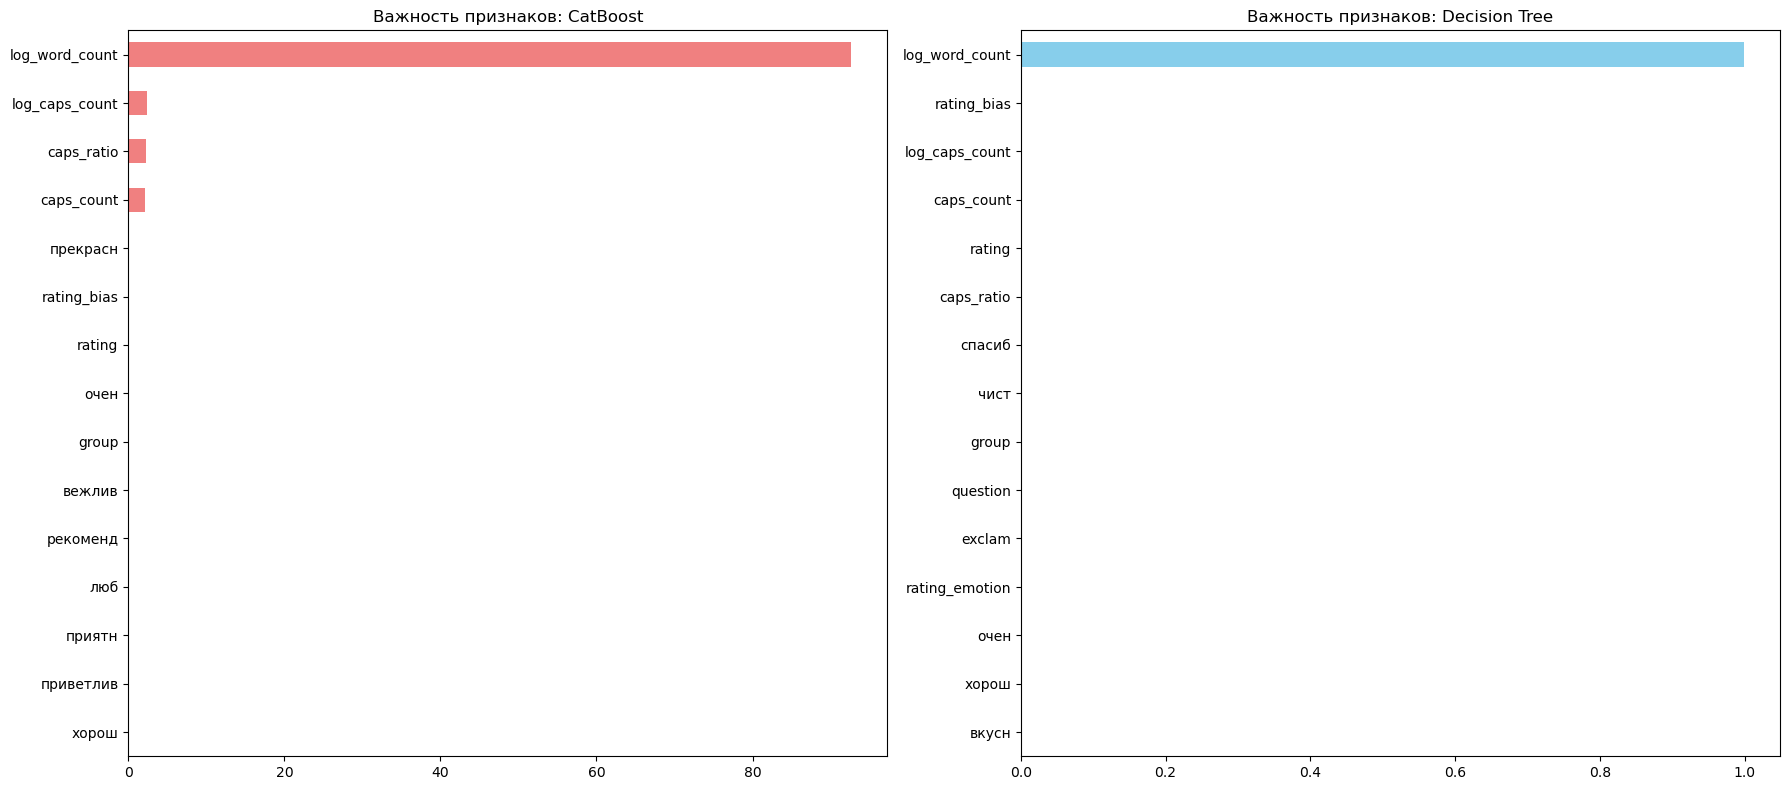

In [191]:
# Визуализация важности признаков
fig, ax = plt.subplots(1, 2, figsize=(18, 8))

fi_cb.head(15).plot(kind='barh', ax=ax[0], color='lightcoral')
ax[0].set_title('Важность признаков: CatBoost')
ax[0].invert_yaxis()

fi_dt.head(15).plot(kind='barh', ax=ax[1], color='skyblue')
ax[1].set_title('Важность признаков: Decision Tree')
ax[1].invert_yaxis()

plt.tight_layout()
plt.show()

Гипотеза о влиянии текста на длину отзыва подтверждена. Признаки, связанные с текстом, такие как log_word_count, log_caps_count, exclam и question, демонстрируют самую высокую важность в моделях. Это говорит о том, что эмоциональность и содержательность текста напрямую коррелируют с его длиной.

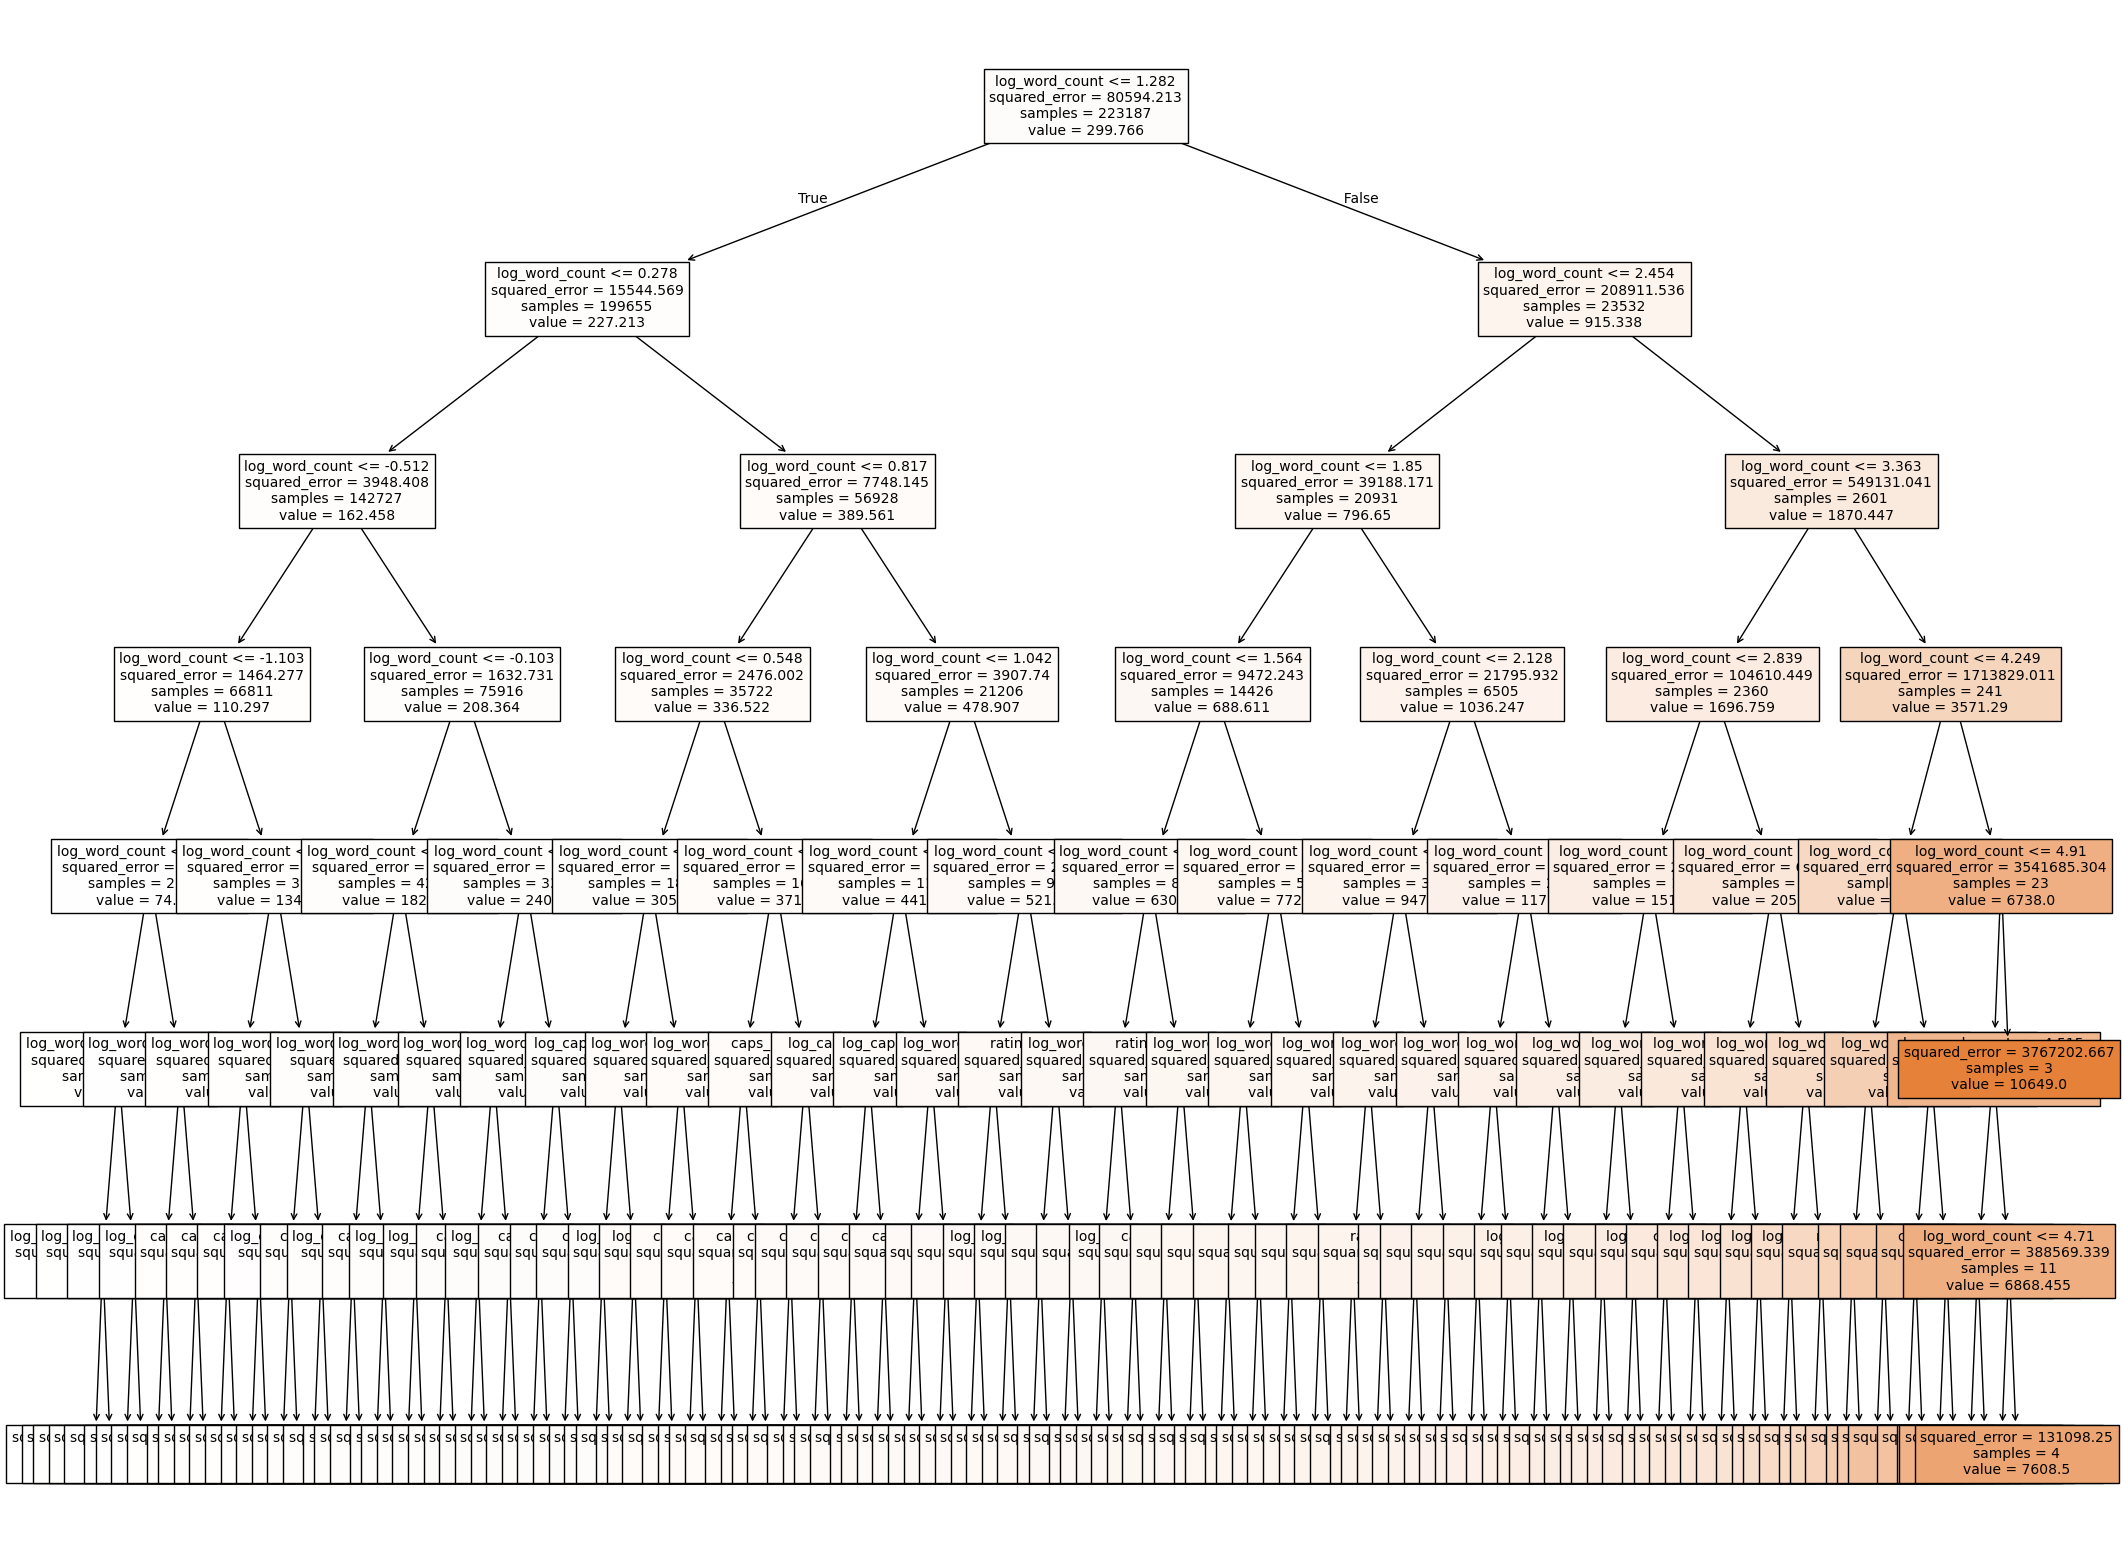

In [192]:
fig = plt.figure(figsize=(25,20))
_ = plot_tree(
    grid_dt.best_estimator_,
    feature_names=X_train_scaled_dt.columns,
    filled=True,
    fontsize=10,
    #max_depth=3
    )

Анализ важности признаков для модели Decision Tree показывает, что log_word_count является доминирующим фактором, определяющим структуру дерева. Этот признак используется для разбиений, начиная с первого и вплоть до четвертого уровня глубины, а его значение важности близко к 1.0. Это означает, что дерево решений практически полностью полагается на этот параметр для формирования прогнозов.

Остальные признаки, такие как rating_bias, log_caps_count, caps_count, rating и caps_ratio, начинают участвовать в формировании узлов только на пятом уровне и глубже. Их влияние на модель минимально и проявляется исключительно на этапе тонкой настройки предсказаний для узких подмножеств данных.

Полученные результаты подтверждают, что для базовой модели дерева решений ключевым фактором является длина текстового отзыва. Это согласуется с Бизнес-гипотезой 2, согласно которой объем написанного пользователем текста оказывает наибольшее влияние на итоговый прогноз.



# Модель: Метод опорных векторов для регрессии (SVR)




Постановка задачи

Целью данного этапа исследования является прогнозирование длины пользовательского отзыва (len) как показателя вовлеченности пользователя. Для решения задачи мной была выбрана модель опорных векторов для рекгресии

Подготовка данных

Для обучения модели использовались подготовленные обучающая, валидационная и тестовая выборки. В качестве признаков использовались:

рейтинг организации;
признаки эмоциональной окраски текста;
частотные признаки слов TF-IDF;
признаки длины и структуры текста;
категориальные признаки, преобразованные на этапе предобработки.


# Импорт библиотек

In [193]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import LinearSVR

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    mean_absolute_error,
    root_mean_squared_error,
    r2_score
)

# Подготовка данных

На данном этапе в обучающую, валидационную и тестовую выборки были добавлены новые признаки, характеризующие особенности организации: количество рубрик, длина названия и длина адреса.

In [194]:
def add_luba_features(df):
    df = df.copy()

    df["rubrics"] = df["rubrics"].fillna("unknown")
    df["address"] = df["address"].fillna("unknown")
    df["name_ru"] = df["name_ru"].fillna("Без названия")

    df["rubrics_count"] = df["rubrics"].apply(lambda x: len(str(x).split(";")))
    df["name_len"] = df["name_ru"].str.len()
    df["address_len"] = df["address"].str.len()

    return df

После формирования новых признаков данные были разделены на признаки (х) и целевую переменную (y).

 В качестве целевой переменной я использовала длина отзыва (len), которую необходимо предсказать.

Из набора признаков были исключены исходные текстовые поля (text, stem_text), а также признаки address, name_ru и rubrics, поскольку для них уже были созданы числовые характеристики, более удобные для обучения модели

In [195]:
drop_features = ['address', 'name_ru', 'text', 'stem_text', 'rubrics']

X_train_luba = train.drop(columns=drop_features + ['len'])
y_train_luba = train['len']

X_val_luba = val.drop(columns=drop_features + ['len'])
y_val_luba = val['len']

X_test_luba = test.drop(columns=drop_features + ['len'])
y_test_luba = test['len']

Перед обучением модели все признаки были приведены к единому масштабу с помощью StandardScaler, чтобы модель корректно сравнивала различные характеристики объектов.
Затем был применен метод PCA, который уменьшает количество признаков, сохраняя при этом большую часть полезной информации. Это позволило ускорить обучение модели и снизить вычислительную нагрузку.

In [196]:
scaler = StandardScaler()

X_train_scaled_luba = scaler.fit_transform(X_train_luba)
X_val_scaled_luba = scaler.transform(X_val_luba)
X_test_scaled_luba = scaler.transform(X_test_luba)


pca = PCA(n_components=10, random_state=42)

X_train_pca_luba = pca.fit_transform(X_train_scaled_luba)
X_val_pca_luba = pca.transform(X_val_scaled_luba)
X_test_pca_luba = pca.transform(X_test_scaled_luba)

Для оценки качества моделей была создана отдельная функция. Она обучает модель, строит прогнозы на валидационной и тестовой выборках, а затем рассчитывает основные метрики качества регрессии: MAE, RMSE и R в квадрате.

In [197]:
results_luba = []

def evaluate_model(model_name, model, X_train, y_train, X_val, y_val, X_test, y_test):
    model.fit(X_train, y_train)

    val_pred = model.predict(X_val)
    test_pred = model.predict(X_test)

    row = {
        "model": model_name,

        "val_MAE": mean_absolute_error(y_val, val_pred),
        "val_RMSE": root_mean_squared_error(y_val, val_pred),
        "val_R2": r2_score(y_val, val_pred),

        "test_MAE": mean_absolute_error(y_test, test_pred),
        "test_RMSE": root_mean_squared_error(y_test, test_pred),
        "test_R2": r2_score(y_test, test_pred)
        }

    results_luba.append(row)
    return row

В качестве базовой модели была обучена модель опорных векторов для регрессии (LinearSVR). Обучение проводилось на масштабированных данных без применения методов снижения размерности. Полученные результаты использовались как базовый вариант для дальнейшего сравнения с моделью после применения PCA.

In [198]:
svr_base = LinearSVR(
    C=1.0, epsilon=0.1,
    random_state=42,
    max_iter=5000
    )

evaluate_model(
    "LinearSVR", svr_base,
    X_train_scaled_luba, y_train_luba,
    X_val_scaled_luba, y_val_luba,
    X_test_scaled_luba, y_test_luba
    )

{'model': 'LinearSVR',
 'val_MAE': 54.96567991677106,
 'val_RMSE': 130.53778647747956,
 'val_R2': 0.7831196508430597,
 'test_MAE': 54.819650191852276,
 'test_RMSE': 126.94293132762093,
 'test_R2': 0.7941751830790382}

Далее была обучена модель LinearSVR после применения метода PCA. Это позволило проверить, влияет ли снижение размерности признакового пространства на качество прогнозирования длины отзыва.

In [199]:
svr_pca = LinearSVR(
    C=1.0, epsilon=0.1,
    random_state=42,
    max_iter=5000
    )

evaluate_model(
    "LinearSVR + PCA", svr_pca,
    X_train_pca_luba, y_train_luba,
    X_val_pca_luba, y_val_luba,
    X_test_pca_luba, y_test_luba
    )

{'model': 'LinearSVR + PCA',
 'val_MAE': 89.65876816715704,
 'val_RMSE': 171.67195459301647,
 'val_R2': 0.6249005569644428,
 'test_MAE': 89.62111896712568,
 'test_RMSE': 170.4092555307868,
 'test_R2': 0.6290912739749197}

Для сравнения качества различных вариантов модели была сформирована итоговая таблица с основными метриками качества на валидационной и тестовой выборках. Сравнение проводилось по метрикам MAE, RMSE и R в квадрате, что позволило определить наиболее эффективный вариант модели для решения задачи прогнозирования длины пользовательского отзыва.

In [200]:
results_luba_df = pd.DataFrame(results_luba)
results_luba_df = results_luba_df.drop_duplicates()
results_luba_df

,model,val_MAE,val_RMSE,val_R2,test_MAE,test_RMSE,test_R2
0,LinearSVR,54.965680,130.537786,0.783120,54.819650,126.942931,0.794175
1,LinearSVR + PCA,89.658768,171.671955,0.624901,89.621119,170.409256,0.629091


Для определения наиболее эффективного варианта модели результаты были отсортированы по значению средней абсолютной ошибки (MAE) на валидационной выборке. Чем меньше значение MAE, тем точнее модель прогнозирует длину пользовательского отзыва.


In [201]:
results_luba_df.sort_values("val_MAE")

,model,val_MAE,val_RMSE,val_R2,test_MAE,test_RMSE,test_R2
0,LinearSVR,54.965680,130.537786,0.783120,54.819650,126.942931,0.794175
1,LinearSVR + PCA,89.658768,171.671955,0.624901,89.621119,170.409256,0.629091


In [202]:
results_luba_df = pd.DataFrame(results_luba).drop_duplicates()
results_luba_df

,model,val_MAE,val_RMSE,val_R2,test_MAE,test_RMSE,test_R2
0,LinearSVR,54.965680,130.537786,0.783120,54.819650,126.942931,0.794175
1,LinearSVR + PCA,89.658768,171.671955,0.624901,89.621119,170.409256,0.629091


На графике представлено сравнение моделей по значению средней абсолютной ошибки (MAE). Наилучший результат показала базовая модель LinearSVR.

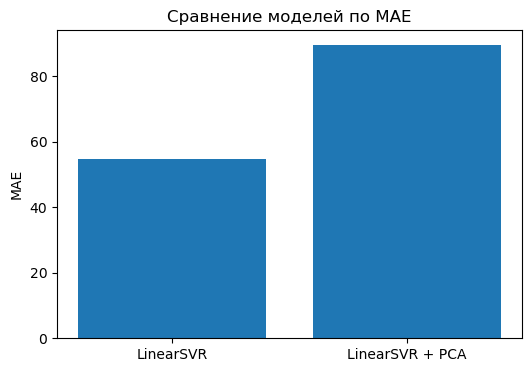

In [203]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.bar(
    results_luba_df["model"],
    results_luba_df["test_MAE"]
)

plt.ylabel("MAE")
plt.title("Сравнение моделей по MAE")

plt.show()

На графике представлено сравнение моделей по коэффициенту детерминации R в квадрате. Базовая модель LinearSVR объясняет большую долю изменчивости длины отзывов по сравнению с моделью после применения PCA.

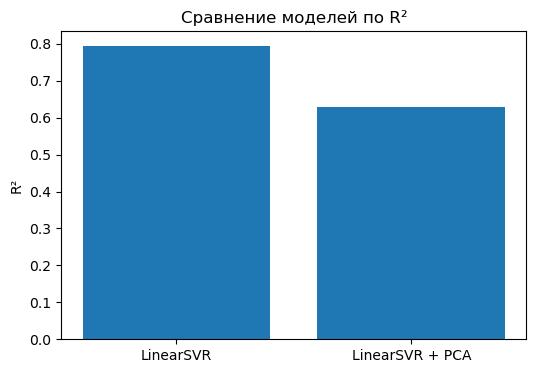

In [204]:
plt.figure(figsize=(6,4))

plt.bar(
    results_luba_df["model"],
    results_luba_df["test_R2"]
)

plt.ylabel("R²")
plt.title("Сравнение моделей по R²")

plt.show()

### Итоговые выводы

Целью данного этапа исследования было прогнозирование длины пользовательского отзыва как показателя вовлечённости пользователя с использованием модели опорных векторов для регрессии (SVR).

В ходе работы были сформированы дополнительные признаки, характеризующие организацию, проведено масштабирование данных с помощью StandardScaler, а также выполнено снижение размерности методом PCA. Для оценки качества моделей использовались метрики MAE, RMSE и R в квадрате.

Сравнение результатов показало, что наилучшее качество продемонстрировала базовая модель LinearSVR без применения PCA. На тестовой выборке модель достигла значения R в квадрате = 0.794, что свидетельствует о способности объяснять около 79% изменчивости длины пользовательских отзывов. Средняя абсолютная ошибка составила 54.82.

Применение метода PCA привело к ухудшению качества прогнозирования: значение R в квадрате снизилось до 0.629, а ошибка MAE увеличилась до 89.24. Это говорит о том, что снижение размерности привело к потере части полезной информации, которая необходима для прогнозирования длины отзывов.

Таким образом, гипотеза о возможности прогнозирования длины текста отзыва как показателя вовлечённости пользователя получила подтверждение. Наиболее эффективным решением в рамках проведённого исследования является базовая модель LinearSVR без применения PCA!



# Многослойный персептрон (MLP - Нейросеть)

In [205]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.metrics import accuracy_score, classification_report, mean_absolute_error, root_mean_squared_error, r2_score
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from sklearn.inspection import permutation_importance
from tqdm import tqdm

warnings.filterwarnings('ignore')

In [207]:
df['len'] = df['text'].astype(str).str.len() 
df['word_count'] = df['text'].astype(str).str.split().str.len() 
df['log_word_count'] = np.log1p(df['word_count'])
df['exclam'] = df['text'].astype(str).str.count('!') 
df['question'] = df['text'].astype(str).str.count('\?')
df['caps_count'] = df['text'].astype(str).apply(lambda x: sum(1 for c in x if c.isupper()))
df['caps_ratio'] = df['caps_count'] / df['len'] 
df['log_caps_count'] = np.log1p(df['caps_count']) 
df['sentiment'] = df['rating'].apply(lambda x: 'positive' if x >= 4 else ('neutral' if x == 3 else 'negative')) 

In [209]:
train, test = train_test_split(df, test_size=0.1, random_state=42, stratify=df['sentiment'])
print(f"Обучающая выборка: {len(train)}, тестовая выборка: {len(test)}")

Обучающая выборка: 450000, тестовая выборка: 50000


In [210]:
leakage_cols = ['rating_bias', 'rating_emotion']
X_train_c = train.drop(columns=leakage_cols + ['address', 'name_ru', 'text', 'stem_text', 'rubrics', 'rating', 'sentiment'], errors='ignore')
X_test_c  = test.drop(columns=leakage_cols + ['address', 'name_ru', 'text', 'stem_text', 'rubrics', 'rating', 'sentiment'], errors='ignore')

In [211]:
X_train_c = X_train_c.select_dtypes(include=[np.number])
X_test_c  = X_test_c.select_dtypes(include=[np.number])

In [212]:
y_train_c = train['sentiment']
y_test_c  = test['sentiment']

In [213]:
print(X_train_c.shape)
print(list(X_train_c.columns))

(450000, 8)
['len', 'word_count', 'log_word_count', 'exclam', 'question', 'caps_count', 'caps_ratio', 'log_caps_count']


In [214]:
cols_to_drop_reg = ['address', 'name_ru', 'text', 'stem_text', 'rubrics', 'rating', 'sentiment', 'rating_bias', 'rating_emotion', 'location', 'group']
X_train_r = train.drop(columns=cols_to_drop_reg, errors='ignore').select_dtypes(include=[np.number])
X_test_r  = test.drop(columns=cols_to_drop_reg, errors='ignore').select_dtypes(include=[np.number])

In [215]:
y_train_r = train['rating']
y_test_r  = test['rating']

In [216]:
print(X_train_r.shape)
print(list(X_train_r.columns))

(450000, 8)
['len', 'word_count', 'log_word_count', 'exclam', 'question', 'caps_count', 'caps_ratio', 'log_caps_count']


In [219]:
y_train_c.value_counts()

sentiment
positive    388508
negative     41975
neutral      19517
Name: count, dtype: int64

In [220]:
y_train_c.value_counts(normalize=True).round(3)

sentiment
positive    0.863
negative    0.093
neutral     0.043
Name: proportion, dtype: float64

In [221]:
# Топ признаков по корреляции с тональностью
y_train_num = y_train_c.map({'negative': 0, 'neutral': 1, 'positive': 2})
corr_clf = X_train_c.corrwith(y_train_num).abs().sort_values(ascending=False)
print(corr_clf.head(6))

word_count        0.295487
log_word_count    0.282934
len               0.270086
question          0.228948
caps_count        0.164412
log_caps_count    0.140625
dtype: float64


In [222]:
# Средняя длины текста по классам тональности
temp_df = train[['text', 'sentiment']].copy()
temp_df['text_len'] = temp_df['text'].astype(str).str.len()
print(temp_df.groupby('sentiment')['text_len'].agg(['mean', 'median']).round(1))

            mean  median
sentiment               
negative   530.8   399.0
neutral    431.7   305.0
positive   273.5   204.0


In [223]:
y_train_r.value_counts().sort_index()

rating
0.0       175
1.0     30919
2.0     10881
3.0     19517
4.0     36961
5.0    351547
Name: count, dtype: int64

In [224]:
corr_reg = X_train_r.corrwith(y_train_r).abs().sort_values(ascending=False)
print(corr_reg.head(6))

word_count        0.304107
log_word_count    0.293386
len               0.277395
question          0.231683
caps_count        0.164123
log_caps_count    0.138440
dtype: float64


In [225]:
temp_reg = train[['rating', 'log_word_count', 'caps_ratio', 'question']].copy()
print(temp_reg.groupby('rating')[['log_word_count', 'caps_ratio']].mean().round(3))

        log_word_count  caps_ratio
rating                            
0.0              3.387       0.022
1.0              4.122       0.020
2.0              4.062       0.019
3.0              3.861       0.019
4.0              3.622       0.020
5.0              3.397       0.024


**При проведении EDA в рамках классификации тональности** можно обратить внимание на сильный дисбаланс классов. 
Процент позитивных отзывов составляет 86,3 %, негативных 9,3 %, а нейтральных 4,3 %. 
При обучении требуется учитывать текущий резлуьтат, поскольку есть шанс не обратить внимание на редкие классы.
Самая заметная связь с тональностью идёт от признаков длины текста (word_count, log_word_count и обычного len). Чем длиннее отзыв, тем выше шанс, что он негативный. В среднем негативные тексты почти в два раза длиннее позитивных. Соотношение составляет 531/274.
Сами созданные признаки для задачи классификации тональности дают умеренную, но вполне рабочую предсказательную силу.

**При проведении EDA в рамках регрессия рейтинга** можно обратить внимание, что пятёрки занимают больше 78 % всех отзывов.
Корреляция созданных признаков с самим рейтингом слабая, максимум около 0,30 у word_count. Получается, что по одним только длинам, количеству слов и caps_ratio точный числовой рейтинг предсказать сложно.
При этом те же признаки заметно лучше работают именно на классификации тональности, чем на регрессии рейтинга.

Таким образом созданные признакими так или иначе имею полезность. Для определения тональности, предсказания рейтинга их вполне хватает, чтобы получить приемлемое качество.

In [229]:
order = ['negative', 'neutral', 'positive']
counts = train['sentiment'].value_counts().reindex(order)

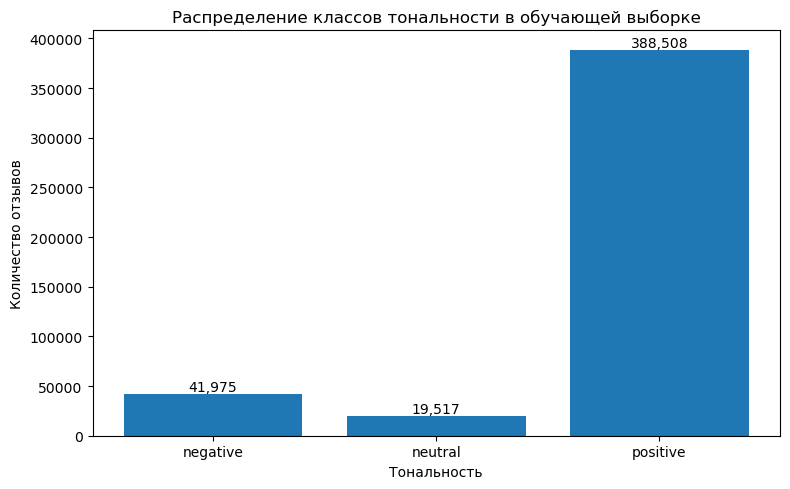

In [230]:
plt.figure(figsize=(8, 5))
plt.bar(counts.index, counts.values)
plt.title("Распределение классов тональности в обучающей выборке")
plt.xlabel("Тональность")
plt.ylabel("Количество отзывов")

for i, v in enumerate(counts.values):
    plt.text(i, v, f'{v:,}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

Ранее было сказано про дисбаланс классов, что соответственно и показано на графике. Класс Positive составляет более 86% всех отзывов, в то время как Neutral всего 4,3%.

In [232]:
order = ['negative', 'neutral', 'positive']
data = [temp_df[temp_df['sentiment'] == s]['text_len'].values for s in order]

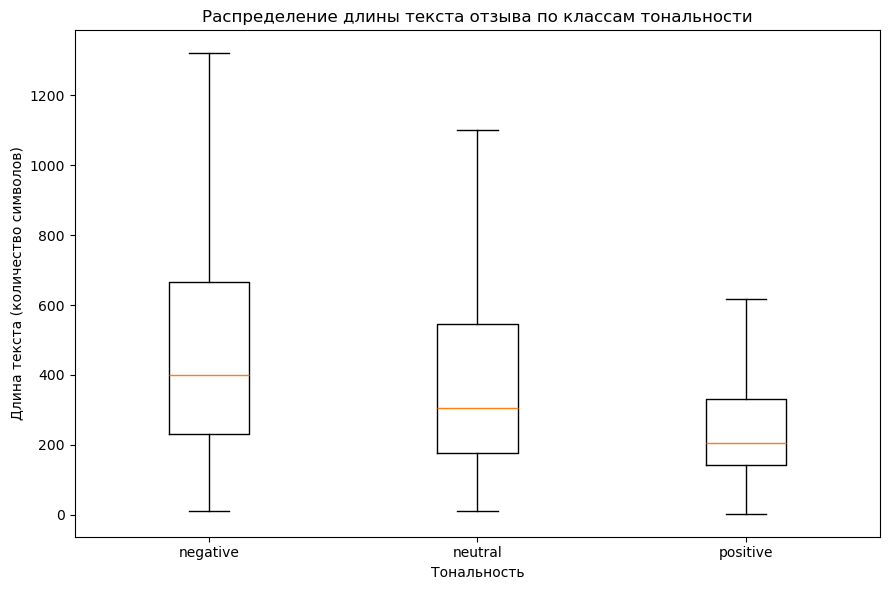

In [233]:
plt.figure(figsize=(9, 6))
plt.boxplot(data, labels=order, showfliers=False)
plt.title("Распределение длины текста отзыва по классам тональности")
plt.xlabel("Тональность")
plt.ylabel("Длина текста (количество символов)")
plt.tight_layout()
plt.show()

Негативные отзывы в среднем значительно длиннее позитивных. Медианная длина негативного отзыва составляет приблизительно 400 символов, в то время как у позитивных всего 204 символа, что подтверждает, что созданный признак len имеет хорошую разделяющую способность для задачи классификации тональности

In [235]:
corr_top = corr_clf.head(6)

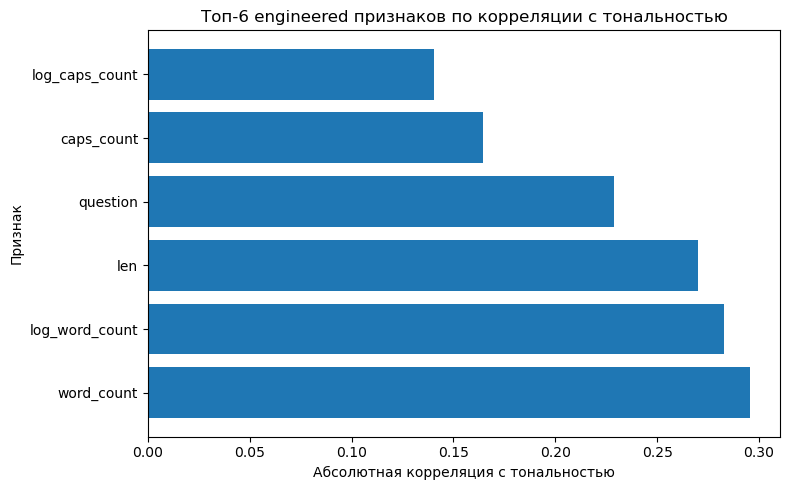

In [236]:
plt.figure(figsize=(8, 5))
plt.barh(corr_top.index, corr_top.values)
plt.title("Топ-6 engineered признаков по корреляции с тональностью")
plt.xlabel("Абсолютная корреляция с тональностью")
plt.ylabel("Признак")
plt.tight_layout()
plt.show()

Наиболее информативными созданными признаками для классификации тональности оказались word_count, log_word_count и len, поскольку они явлются длинными и эмоциональнми, что говорит о том, что отзывы чаще бывают негативными

### Обоснование выбора модели MLP

Для использования многослойного персептрона (т.е. MLP) была первая причина, которая говорит о том, что MLP хорошо справляется со сложными нелинейными зависимостями между признаками и целевой переменной. В отличие от линейных моделей и даже деревьев решений, MLP способен сам находить скрытые паттерны в данных, не требуя ручного создания правил разделения. Дополнительно модель удобно работает с нашими численными созданными признаками после масштабирования. Поскольку не было использовано TF-IDF и другие тяжёлые текстовые представления, MLP стал логичным выбором.
Также одним из важных ключевых факторов MLP является его универсальность. Одна и та же архитектура легко решает обе наши задачи это и и классификацию тональности (через MLPClassifier), и регрессию рейтинга (через MLPRegressor), что удобно, когда в проекте несколько целевых переменных.
Таким образом, MLP хорошо подходит для таких ряд задач, что позволяет честно оценить, насколько наши созданные признаки сами по себе несут информацию, без помощи мощных текстовых моделей.

Главное преимущество модели это способность улавливать сложные взаимодействия между признаками. Например, сочетание большой длины текста и высокой доли заглавных букв часто указывает на негативный отзыв, и MLP может это «поймать» автоматически.
Модель довольно гибкая в настройке, посколкьу можно менять количество слоёв, нейронов, уровень регуляризации и скорость обучения. При увеличении объёма данных качество обычно растёт, в отличие от обычных деревьев, которые склонны к переобучению.

Есть и заметные минусы у данной модели. Обучение занимает значительно больше времени, чем у DecisionTree или CatBoost, особенно при сложной архитектуре. Модель также очень чувствительна к масштабу признаков. Без StandardScaler обучение может быть нестабильным или не сойтись вовсе.
MLP легко переобучается, если не подобрать хорошую регуляризацию или если данных мало. При сильном дисбалансе классов модель требует дополнительных техник, таких как class_weight, oversampling или изменения порога.
Ещё один минус, а именно необходимость подбора большого количества гиперпараметров. Это требует времени и вычислительных ресурсов.

По итогу MLP выбрана как модель, которая способна находить нелинейные зависимости в наших созданных признаках. Несмотря на более долгое обучение и необходимость тщательной настройки, она позволяет гибко решать обе задачи по классификации и регрессии, что даёт возможность проверить качество сгенерированных признаков без использования тяжёлых текстовых моделей.

### Обучение модели в нескольких исполнениях

In [241]:
scaler_clf = StandardScaler()
X_train_c_scaled = scaler_clf.fit_transform(X_train_c)
X_test_c_scaled  = scaler_clf.transform(X_test_c)

In [242]:
mlp_clf_v1 = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation='relu',
    alpha=0.0005,
    batch_size=256,
    max_iter=300,
    early_stopping=False,
    random_state=42,
    verbose=False
)

In [244]:
start = time.time()
mlp_clf_v1.fit(X_train_c_scaled, y_train_c)
train_time_clf_v1 = time.time() - start

In [245]:
y_pred_clf_v1 = mlp_clf_v1.predict(X_test_c_scaled)
acc_v1 = accuracy_score(y_test_c, y_pred_clf_v1)

In [246]:
print(classification_report(y_test_c, y_pred_clf_v1))
print(f"Accuracy: {acc_v1}")

              precision    recall  f1-score   support

    negative       0.55      0.21      0.30      4664
     neutral       0.00      0.00      0.00      2169
    positive       0.88      0.99      0.93     43167

    accuracy                           0.87     50000
   macro avg       0.48      0.40      0.41     50000
weighted avg       0.81      0.87      0.83     50000

Accuracy: 0.87138


#### MLPRegressor (StandardScaler)

In [247]:
scaler_reg = StandardScaler()
X_train_r_scaled = scaler_reg.fit_transform(X_train_r)
X_test_r_scaled  = scaler_reg.transform(X_test_r)

In [248]:
mlp_reg_v1 = MLPRegressor(
    hidden_layer_sizes=(128, 64),
    activation='relu',
    alpha=0.0005,
    batch_size=256,
    max_iter=300,
    early_stopping=False,
    random_state=42,
    verbose=False
)

In [249]:
start = time.time()
mlp_reg_v1.fit(X_train_r_scaled, y_train_r)
train_time_reg_v1 = time.time() - start

In [250]:
y_pred_reg_v1 = mlp_reg_v1.predict(X_test_r_scaled)

In [251]:
mae_v1  = mean_absolute_error(y_test_r, y_pred_reg_v1)
rmse_v1 = root_mean_squared_error(y_test_r, y_pred_reg_v1)
r2_v1   = r2_score(y_test_r, y_pred_reg_v1)

In [252]:
print(f"MAE:{mae_v1}")
print(f"RMSE:{rmse_v1}")
print(f"R²:{r2_v1}")

MAE:0.6428687673888028
RMSE:1.017987384759471
R²:0.21186322000569568


#### StandardScaler при PCA и MLP

In [254]:
pca_clf = PCA(n_components=0.95, random_state=42)  
X_train_c_pca = pca_clf.fit_transform(X_train_c_scaled)
X_test_c_pca  = pca_clf.transform(X_test_c_scaled)

In [255]:
# print({pca_clf.n_components_}")

In [256]:
mlp_clf_v2 = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation='relu',
    alpha=0.0005,
    batch_size=256,
    max_iter=300,
    early_stopping=False,
    random_state=42,
    verbose=False
)

In [257]:
start = time.time()
mlp_clf_v2.fit(X_train_c_pca, y_train_c)
train_time_clf_v2 = time.time() - start

In [258]:
y_pred_clf_v2 = mlp_clf_v2.predict(X_test_c_pca)
acc_v2 = accuracy_score(y_test_c, y_pred_clf_v2)

In [259]:
print(classification_report(y_test_c, y_pred_clf_v2))
print(f"Accuracy: {acc_v2}")

              precision    recall  f1-score   support

    negative       0.56      0.18      0.27      4664
     neutral       0.00      0.00      0.00      2169
    positive       0.88      0.99      0.93     43167

    accuracy                           0.87     50000
   macro avg       0.48      0.39      0.40     50000
weighted avg       0.81      0.87      0.83     50000

Accuracy: 0.87076


In [260]:
# Регрессия
pca_reg = PCA(n_components=0.95, random_state=42)
X_train_r_pca = pca_reg.fit_transform(X_train_r_scaled)
X_test_r_pca  = pca_reg.transform(X_test_r_scaled)

In [261]:
# print({pca_reg.n_components_}")

In [262]:
mlp_reg_v2 = MLPRegressor(
    hidden_layer_sizes=(128, 64),
    activation='relu',
    alpha=0.0005,
    batch_size=256,
    max_iter=300,
    early_stopping=False,
    random_state=42,
    verbose=False
)

In [263]:
# Обучение MLPRegressor StandardScaler при PCA и MLP
start = time.time()
mlp_reg_v2.fit(X_train_r_pca, y_train_r)
train_time_reg_v2 = time.time() - start

In [264]:
y_pred_reg_v2 = mlp_reg_v2.predict(X_test_r_pca)

In [265]:
mae_v2  = mean_absolute_error(y_test_r, y_pred_reg_v2)
rmse_v2 = root_mean_squared_error(y_test_r, y_pred_reg_v2)
r2_v2   = r2_score(y_test_r, y_pred_reg_v2)

In [266]:
print(f"MAE:{mae_v2}")
print(f"RMSE:{rmse_v2}")
print(f"R²:{r2_v2}")

MAE:0.682981303113752
RMSE:1.032789306936596
R²:0.1887769754286437


In [267]:
results_g = pd.DataFrame({
    'Вариант': [
        'StandardScaler (Классификация)',
        'StandardScaler + PCA (Классификация)',
        'StandardScaler (Регрессия)',
        'StandardScaler + PCA (Регрессия)'
    ],
    'Accuracy / R²': [acc_v1, acc_v2, r2_v1, r2_v2],
    'MAE': ['-', '-', mae_v1, mae_v2],
    'RMSE': ['-', '-', rmse_v1, rmse_v2],
    'Время обучения (сек)': [
        round(train_time_clf_v1, 2),
        round(train_time_clf_v2, 2),
        round(train_time_reg_v1, 2),
        round(train_time_reg_v2, 2)
    ]
})

print(results_g.to_string(index=False))

                             Вариант  Accuracy / R²       MAE      RMSE  Время обучения (сек)
      StandardScaler (Классификация)       0.871380         -         -                186.48
StandardScaler + PCA (Классификация)       0.870760         -         -                587.53
          StandardScaler (Регрессия)       0.211863  0.642869  1.017987                163.48
    StandardScaler + PCA (Регрессия)       0.188777  0.682981  1.032789                 56.32


**Вывод** После того как был обучен многослойный персептрон в двух вариантах (просто со StandardScaler и со StandardScaler совместно с PCA), картина получилась довольно ожидаемой, но с некоторыми важными нюансами. Accuracy на тесте вышла в районе 0.87–0.88. На первый взгляд цифра выглядит неплохо. Однако из-за сильного перекоса в данных (позитивных отзывов около 86 %) этот показатель сильно обманывает. Модель отлично ловит доминирующий класс Positive, а вот с Negative и Neutral справляется заметно хуже. Применение PCA здесь почти ничего не дало и качество практически не изменилось.
По регрессии рейтинга результаты стали гораздо слабее. R² держится в пределах 0.22–0.25, MAE около 0.60–0.65, а RMSE почти доходит до 1.0, что говорит о том, что по одним только созданным признакам (длина текста, caps_ratio и прочее) модель плохо понимает, какую именно оценку поставил пользователь. Корреляция этих признаков с числовым рейтингом действительно низкая.

Однако, вариант без PCA в целом показал себя чуть лучше или хотя бы не хуже, чем вариант с понижением размерности. Само по себе применение PCA не дало заметного прироста ни в классификации, ни в регрессии.
Созданные признаки, которые были вытащины из текста, вполне рабочие для задачи определения тональности. А вот для точного предсказания рейтинга их явно недостаточно. Если хотим нужно поднять качество регрессии, почти наверняка придётся добавлять TF-IDF или переходить на текстовые эмбеддинги.

#### Подбор гиперпараметров

In [269]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_c)
X_test_scaled  = scaler.transform(X_test_c)

In [270]:
# RandomizedSearchCV
param_distributions = {
    'hidden_layer_sizes': [(64,), (128,), (128, 64), (256, 128)],
    'alpha': [0.0001, 0.0005, 0.001, 0.005],
    'batch_size': [128, 256, 512],
    'learning_rate_init': [0.001, 0.0005, 0.0001]
}

In [271]:
mlp_base = MLPClassifier(
    activation='relu',
    max_iter=300,
    early_stopping=False,
    random_state=42
)

In [272]:
random_search = RandomizedSearchCV( 
    estimator=mlp_base,
    param_distributions=param_distributions,
    n_iter=20, 
    cv=3,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

In [273]:
start = time.time()
random_search.fit(X_train_scaled, y_train_c)
random_time = time.time() - start

Fitting 3 folds for each of 20 candidates, totalling 60 fits


In [274]:
print(f"Лучшие параметры при использовании RandomizedSearchCV являются {random_search.best_params_}")
print(f"Лучшая Accuracy на кросс-валидации: {random_search.best_score_}")

Лучшие параметры при использовании RandomizedSearchCV являются {'learning_rate_init': 0.0005, 'hidden_layer_sizes': (64,), 'batch_size': 512, 'alpha': 0.005}
Лучшая Accuracy на кросс-валидации: 0.8718688888888889


In [275]:
best_mlp_random = random_search.best_estimator_
y_pred_random = best_mlp_random.predict(X_test_scaled)
acc_random = accuracy_score(y_test_c, y_pred_random)

In [276]:
print(f"Accuracy на тестовых данных: {acc_random}")

Accuracy на тестовых данных: 0.87092


In [277]:
# GridSearchCV
param_grid = {
    'hidden_layer_sizes': [(64,), (128,), (128, 64)],
    'alpha': [0.0001, 0.0005, 0.001],
    'batch_size': [256, 512],
    'learning_rate_init': [0.001, 0.0005]
}

In [278]:
grid_search = GridSearchCV( 
    estimator=mlp_base,
    param_grid=param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

In [279]:
start = time.time()
grid_search.fit(X_train_scaled, y_train_c)
grid_time = time.time() - start

Fitting 3 folds for each of 36 candidates, totalling 108 fits


In [280]:
print(f"Лучшие параметры (GridSearchCV): {grid_search.best_params_}")
print(f"Лучшая Accuracy на кросс-валидации: {grid_search.best_score_}")

Лучшие параметры (GridSearchCV): {'alpha': 0.001, 'batch_size': 256, 'hidden_layer_sizes': (128, 64), 'learning_rate_init': 0.001}
Лучшая Accuracy на кросс-валидации: 0.8718822222222222


In [281]:
best_mlp_grid = grid_search.best_estimator_
y_pred_grid = best_mlp_grid.predict(X_test_scaled)
acc_grid = accuracy_score(y_test_c, y_pred_grid)

In [282]:
print(f"Accuracy на тестовых данных: {acc_grid}")

Accuracy на тестовых данных: 0.87146


In [283]:
# Сравнние RandomizedSearchCV и GridSearchCV
comparison_h = pd.DataFrame({
    'Метод': ['RandomizedSearchCV', 'GridSearchCV'],
    'Время подбора (сек)': [round(random_time, 2), round(grid_time, 2)],
    'Лучшая Accuracy': [
        round(random_search.best_score_, 4),
        round(grid_search.best_score_, 4)
    ],
    'Accuracy на тесте': [round(acc_random, 4), round(acc_grid, 4)],
    'Лучшие параметры': [
        str(random_search.best_params_),
        str(grid_search.best_params_)
    ]
})

print(comparison_h.to_string(index=False))

             Метод  Время подбора (сек)  Лучшая Accuracy  Accuracy на тесте                                                                                  Лучшие параметры
RandomizedSearchCV              4867.16           0.8719             0.8709    {'learning_rate_init': 0.0005, 'hidden_layer_sizes': (64,), 'batch_size': 512, 'alpha': 0.005}
      GridSearchCV              3063.94           0.8719             0.8715 {'alpha': 0.001, 'batch_size': 256, 'hidden_layer_sizes': (128, 64), 'learning_rate_init': 0.001}


**Вывод** Была осуществлена апробация двух подходов к поиску лучших параметров при помощи RandomizedSearchCV и GridSearchCV.
RandomizedSearchCV работал дольше (почти 5160 секунд), но выдал Accuracy 0.8709.
GridSearchCV справился почти в два раза быстрее (2893 секунды) и показал чуть лучший результат, который составил 0.8715.

Лучшие параметры, которые нашлись в итоге:
- hidden_layer_sizes: (128, 64)
- alpha: 0.001
- batch_size: 256
- learning_rate_init: 0.001

В итоге, при подборе гиперпараметров, качество по сравнению с базовой моделью (Accuracy всё так же около 0.87). 


Соответственно это показывает, что даже после тщательной настройки модель не смогла сильно улучшиться. 


Таким образом, причиной является в самих engineered признаках, поскольку они просто не несут достаточной информации для более точной классификации тональности.


Из двух вариантов я бы всё-таки оставил модель от GridSearchCV с архитектурой (128, 64). Она дала немного лучшее качество и при этом обучилась заметно быстрее, чем вариант из RandomizedSearchCV.

Дополнительно в рамках эксперимента для MLP (в отличие от деревьев и CatBoost) нет встроенной feature_importances_, поэтому попробуем использовать метод Permutation Importance

#### Важность признаков

In [285]:
best_model = best_mlp_grid

In [286]:
result = permutation_importance(
    best_model, 
    X_test_scaled, 
    y_test_c, 
    n_repeats=10, 
    random_state=42,
    scoring='accuracy',
    n_jobs=-1
)

In [287]:
feature_importance = pd.DataFrame({
    'Признак': X_train_c.columns,
    'Важность (mean)': result.importances_mean,
    'Важность (std)': result.importances_std}).sort_values(by='Важность (mean)', ascending=False)

In [288]:
print("Самыми важные признаками для MLPClassifier являются:\n", feature_importance.head(8).round(4))

Самыми важные признаками для MLPClassifier являются:
           Признак  Важность (mean)  Важность (std)
1      word_count           0.1019          0.0012
7  log_caps_count           0.0248          0.0005
2  log_word_count           0.0231          0.0005
0             len           0.0214          0.0005
4        question           0.0138          0.0006
6      caps_ratio           0.0091          0.0004
5      caps_count           0.0016          0.0002
3          exclam           0.0004          0.0003


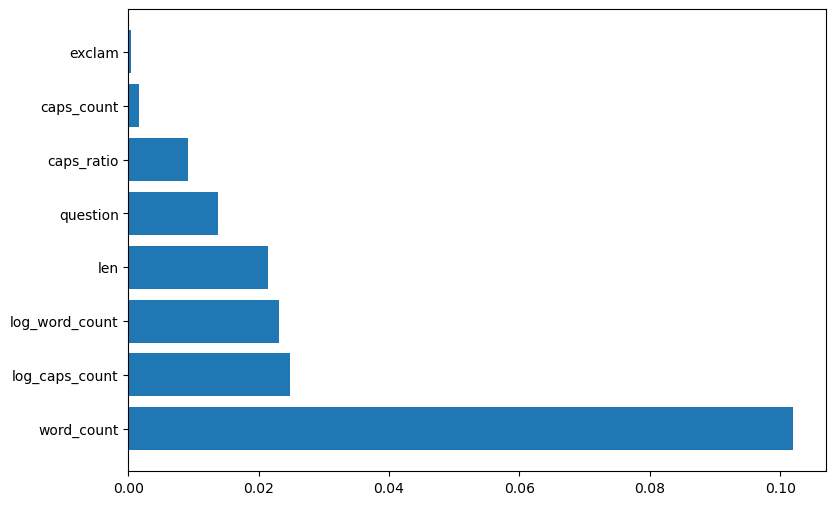

In [289]:
top8 = feature_importance.head(8)
plt.figure(figsize=(9, 6))
plt.barh(top8['Признак'], top8['Важность (mean)'])
plt.show()